# 🌦️ AgriTwin-GH — Weather Forecast Model
**Multi-Horizon Environmental Forecasting: 24-Hour & 48-Hour Predictions**

---

## Overview
This notebook trains a multi-horizon weather forecasting model for **Dindigul District, Tamil Nadu**, predicting all meteorological variables at **+24 h** and **+48 h** ahead from the current observation.

### District-Specific Context
Dindigul sits at ~10.4°N, ~77.9°E, 450 m elevation in the Palani Hills rain-shadow zone. Its climate has **four distinct local seasons**:

| Season | Months | Character |
|--------|--------|-----------|
| **Hemant/Winter** | Jan – Feb | Cool, dry, post-NE monsoon tail |
| **Grishma/Summer** | Mar – May | Hot, low humidity, pre-monsoon |
| **Varsha/SW Monsoon** | Jun – Sep | High humidity, moderate rain |
| **Sharad/NE Monsoon** | Oct – Dec | Rain peaks, humid |

### Prediction Targets
| Variable | Type | Unit |
|----------|------|------|
| `temp` | Continuous | °C |
| `humidity` | Continuous | % |
| `windspeed` | Continuous | km/h |
| `solarradiation` | Continuous | W/m² |
| `conditions` | Categorical | Label |

### Model Stack
1. **Amazon Chronos-T5-small** — pretrained time-series foundation model → zero-shot baseline → warm-up fine-tune → full fine-tune
2. **XGBoost** — gradient-boosted ensemble with rich feature engineering
3. **Temporal Fusion Transformer (TFT)** — interpretable multi-horizon deep learning
4. **Conditions Classifier** — RandomForest predicting sky-condition label from numeric forecasts
5. **Ensemble** — optimised weighted blend of all numeric regressors

### Accuracy Target: ≥ 95% (MAPE ≤ 5%)

In [9]:
# ── 0. Package Installation ──────────────────────────────────────────────────
# Run this cell once. Restart kernel afterward if installing for the first time.
import subprocess, sys

_packages = [
    "chronos-forecasting",   # Amazon pretrained time-series model
    "lightgbm",              # Light gradient boosting (ensemble backbone)
    "statsmodels",           # SARIMA / STL decomposition helpers
    "optuna",                # Hyper-parameter + ensemble-weight optimisation
    "shap",                  # SHAP feature importance for XGBoost
    "plotly",                # Interactive plots
    "neuralforecast",        # N-HiTS auxiliary model
]

for _pkg in _packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", _pkg, "-q"],
        check=False,
    )
print("✅ All auxiliary packages installed (or already present).")

✅ All auxiliary packages installed (or already present).


In [59]:
# ── 1. Imports & Configuration ────────────────────────────────────────────────
import os, json, uuid, random, warnings, datetime, joblib
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score,
    accuracy_score, classification_report, confusion_matrix,
)
from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb

import shap

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader as TorchDataLoader

from chronos import ChronosPipeline

# pytorch-forecasting only needed for conditions classifier (RF via sklearn)
# TFT removed – replaced by custom BiLSTM

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

# ── Runtime ID ────────────────────────────────────────────────────────────────
# Try to reuse existing RUN_ID from globals; otherwise create new
if "RUN_ID" in globals():
    print(f"🆔  Reusing existing Run ID: {RUN_ID}")
else:
    RUN_TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    RUN_ID = f"{RUN_TIMESTAMP}"
    print(f"🆔  New Run ID: {RUN_ID}")

# ── Repo root — derived from this notebook's location ────────────────────────
REPO_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() \
    else Path().resolve().parent   # Jupyter: cwd is notebooks/, parent = repo root
print(f"📁  Repo root : {REPO_ROOT}")

CONFIG = {
    # ─ Paths ─────────────────────────────────────────────────────────────────
    "repo_root"      : str(REPO_ROOT),
    "data_dir"       : str(REPO_ROOT / "data/external/Weather Data"),
    "models_dir"     : str(REPO_ROOT / "src/agritwin_gh/models"),
    "artifacts_base" : str(REPO_ROOT / "src/agritwin_gh/models/artifacts"),
    "run_id"         : RUN_ID,
    # ─ Columns ───────────────────────────────────────────────────────────────
    "target_cols"    : ["temp", "humidity", "windspeed", "solarradiation"],
    "cat_target"     : "conditions",
    # ─ Feature Engineering ───────────────────────────────────────────────────
    "lag_days"       : [1, 2, 3, 7, 14, 30],
    "rolling_windows": [7, 14, 30],
    "context_length" : 30,          # days of history fed to models
    "prediction_length": 2,         # horizons: t+1 (24h) & t+2 (48h)
    # ─ Train / Val / Test ────────────────────────────────────────────────────
    "val_fraction"   : 0.15,
    "test_fraction"  : 0.15,
    "random_seed"    : 42,
    # ─ Chronos ───────────────────────────────────────────────────────────────
    "chronos_model"           : "amazon/chronos-t5-small",
    "chronos_context_length"  : 30,
    "chronos_warmup_epochs"   : 5,
    "chronos_finetune_epochs" : 10,
    "chronos_warmup_lr"       : 1e-3,
    "chronos_finetune_lr"     : 1e-4,
    "chronos_batch_size"      : 16,
    # ─ XGBoost ────────────────────────────────────────────────────────────────
    "xgb_n_estimators"        : 600,
    "xgb_learning_rate"       : 0.04,
    "xgb_max_depth"           : 4,       # reduced from 5 (less overfit on small data)
    "xgb_subsample"           : 0.8,
    "xgb_colsample_bytree"    : 0.75,
    "xgb_reg_alpha"           : 0.1,
    "xgb_reg_lambda"          : 2.0,
    "xgb_min_child_weight"    : 5,       # regularise leaf splits
    "xgb_gamma"               : 0.05,    # min gain to split a node
    # ─ LSTM (replaces TFT) ───────────────────────────────────────────────────
    "lstm_hidden_size"        : 128,     # hidden units per direction
    "lstm_n_layers"           : 2,       # stacked LSTM layers
    "lstm_dropout"            : 0.3,     # dropout between LSTM layers + head
    "lstm_epochs"             : 100,
    "lstm_lr"                 : 1e-3,
    "lstm_batch_size"         : 32,
    "lstm_patience"           : 20,      # early-stopping patience
    # ─ Variable-Specific LSTM Tuning (balanced aggressive) ─────────────────
    "lstm_dropout_per_col"    : {"temp": 0.25, "humidity": 0.10, "windspeed": 0.05, "solarradiation": 0.25},
    "lstm_lr_per_col"         : {"temp": 1e-3, "humidity": 2e-4, "windspeed": 1e-4, "solarradiation": 1e-3},
    # ─ Per-horizon LSTM dropout (48h gets strong regularization) ────────────
    "lstm_dropout_per_horizon": {1: 0.00, 2: 0.15},  # 48h gets strong dropout
    # ─ Variable-Specific XGBoost Tuning (balanced for good performance) ─────
    "xgb_max_depth_per_col"   : {"temp": 4, "humidity": 2, "windspeed": 1, "solarradiation": 4},
    "xgb_reg_lambda_per_col"  : {"temp": 2.0, "humidity": 6.0, "windspeed": 20.0, "solarradiation": 2.0},
    "xgb_reg_alpha_per_col"   : {"temp": 0.1, "humidity": 0.5, "windspeed": 2.0, "solarradiation": 0.1},
    "xgb_min_child_weight_per_col": {"temp": 5, "humidity": 15, "windspeed": 15, "solarradiation": 5},
    # ─ Ensemble ───────────────────────────────────────────────────────────────
    "ensemble_n_trials"       : 1200,    # balanced ensemble tuning
}

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Device  : {DEVICE}")

import random as _rng_lib
_rng_lib.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])
torch.manual_seed(CONFIG["random_seed"])

TARGET_COLS = CONFIG["target_cols"]
HORIZONS    = [1, 2]   # 1 → 24 h, 2 → 48 h
HORIZON_TAG = {1: "24h", 2: "48h"}

🆔  Reusing existing Run ID: 20260319_114027
📁  Repo root : E:\AgriTwin-GH
🖥️  Device  : cpu


In [11]:
# ── 2. Data Loading & Initial Preprocessing ───────────────────────────────────
data_dir = Path(CONFIG["data_dir"])

df_2024 = pd.read_csv(data_dir / "dindigul_weather_2024.csv")
df_2025 = pd.read_csv(data_dir / "dindigul_weather_2025.csv")

df = pd.concat([df_2024, df_2025], ignore_index=True)

# Parse datetime
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

# Drop duplicate dates if any
df = df.drop_duplicates(subset=["datetime"]).reset_index(drop=True)

# Fix numeric columns (sometimes read as string due to commas in 'conditions')
for col in TARGET_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ─ Derived time components ────────────────────────────────────────────────────
df["year"]       = df["datetime"].dt.year
df["month"]      = df["datetime"].dt.month
df["day"]        = df["datetime"].dt.day
df["dayofyear"]  = df["datetime"].dt.dayofyear
df["dayofweek"]  = df["datetime"].dt.dayofweek   # 0=Mon ... 6=Sun
df["weekofyear"] = df["datetime"].dt.isocalendar().week.astype(int)

# ─ Sunrise / Sunset derived features ─────────────────────────────────────────
df["sunriseEpoch"] = pd.to_numeric(df["sunriseEpoch"], errors="coerce")
df["sunsetEpoch"]  = pd.to_numeric(df["sunsetEpoch"],  errors="coerce")
df["day_length_h"] = (df["sunsetEpoch"] - df["sunriseEpoch"]) / 3600.0

# ─ Clean conditions text ──────────────────────────────────────────────────────
df["conditions"] = df["conditions"].str.strip()

print(f"📅 Date range : {df['datetime'].min().date()} → {df['datetime'].max().date()}")
print(f"📊 Total rows : {len(df)}")
print(f"📋 Columns    : {list(df.columns)}")
print(f"\n🔍 Missing values:\n{df[TARGET_COLS].isnull().sum()}")
print(f"\n🏷️  Conditions classes ({df['conditions'].nunique()}):")
for c in sorted(df["conditions"].unique()): print(f"   · {c}")

📅 Date range : 2024-01-01 → 2025-12-31
📊 Total rows : 731
📋 Columns    : ['datetime', 'datetimeEpoch', 'temp', 'humidity', 'windspeed', 'solarradiation', 'sunrise', 'sunriseEpoch', 'sunset', 'sunsetEpoch', 'conditions', 'description', 'year', 'month', 'day', 'dayofyear', 'dayofweek', 'weekofyear', 'day_length_h']

🔍 Missing values:
temp              0
humidity          0
windspeed         0
solarradiation    0
dtype: int64

🏷️  Conditions classes (5):
   · Clear
   · Overcast
   · Partially cloudy
   · Rain, Overcast
   · Rain, Partially cloudy


## 1. Exploratory Data Analysis

In [12]:
# ── 3. EDA – Summary Statistics ───────────────────────────────────────────────
print("=" * 70)
print("DESCRIPTIVE STATISTICS — NUMERIC TARGETS")
print("=" * 70)
print(df[TARGET_COLS].describe().round(2).to_string())

print("\n" + "=" * 70)
print("CONDITIONS FREQUENCY")
print("=" * 70)
print(df["conditions"].value_counts().to_string())

DESCRIPTIVE STATISTICS — NUMERIC TARGETS
         temp  humidity  windspeed  solarradiation
count  731.00    731.00     731.00          731.00
mean    28.82     68.39      20.95          214.81
std      2.22      9.38       5.56           61.91
min     21.00     45.60       7.60           19.30
25%     27.00     61.10      16.60          178.90
50%     28.90     68.20      20.50          226.40
75%     30.60     75.35      24.10          260.70
max     33.80     93.30      55.40          322.80

CONDITIONS FREQUENCY
conditions
Partially cloudy          409
Rain, Partially cloudy    281
Clear                      27
Rain, Overcast              9
Overcast                    5


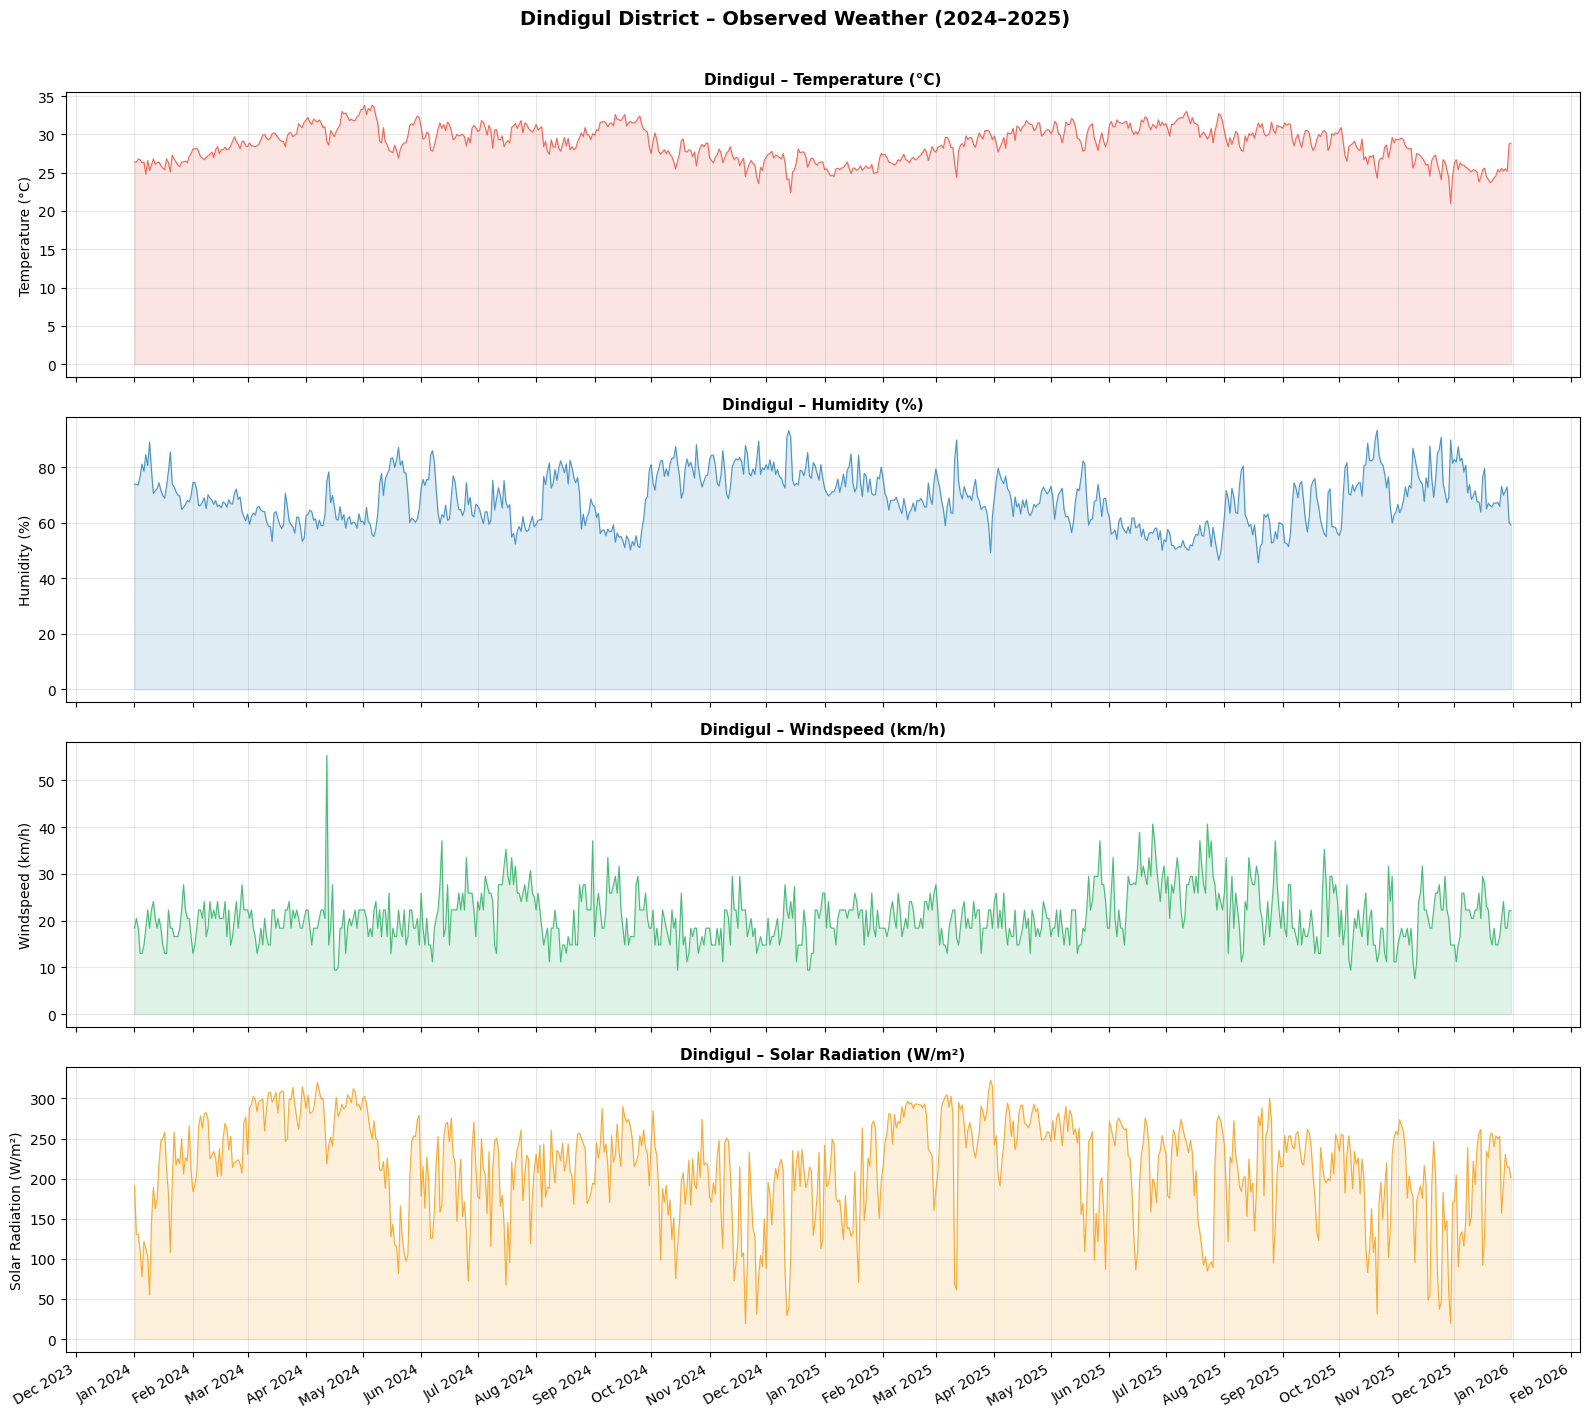

✅ Time-series overview saved → eda_timeseries.png


In [13]:
# ── 4. EDA – Time-Series Visualisation ────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
palette = ["#e74c3c", "#2980b9", "#27ae60", "#f39c12"]

titles = ["Temperature (°C)", "Humidity (%)", "Windspeed (km/h)", "Solar Radiation (W/m²)"]
for ax, col, title, color in zip(axes, TARGET_COLS, titles, palette):
    ax.plot(df["datetime"], df[col], linewidth=0.8, color=color, alpha=0.8)
    ax.fill_between(df["datetime"], df[col], alpha=0.15, color=color)
    ax.set_ylabel(title, fontsize=10)
    ax.set_title(f"Dindigul – {title}", fontsize=11, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.grid(True, alpha=0.3)

plt.xticks(rotation=30, ha="right")
plt.suptitle("Dindigul District – Observed Weather (2024–2025)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("eda_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Time-series overview saved → eda_timeseries.png")

## 2. Dindigul Seasonal Analysis

The district experiences a **tropical semi-arid climate** shaped by both South-West (June–Sep) and North-East (Oct–Dec) monsoons plus a pronounced hot dry summer (Mar–May). All models will encode this four-season calendar as a categorical feature.

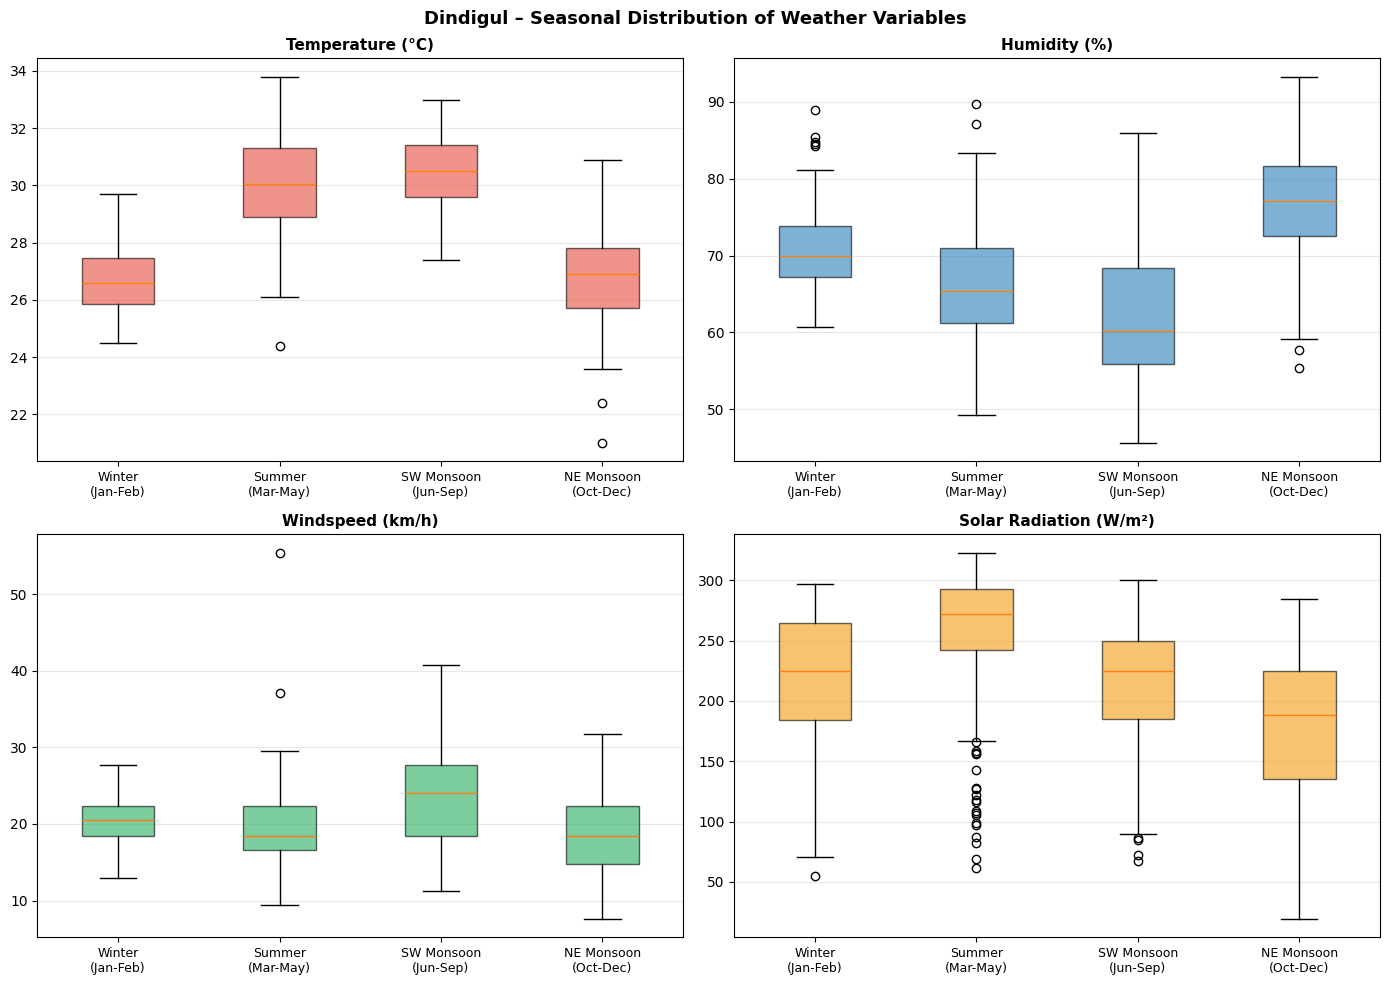


📊 Monthly Means:
        temp  humidity  windspeed  solarradiation
month                                            
1      25.91     74.04      19.72          184.93
2      27.52     67.62      20.77          253.19
3      29.24     64.96      19.32          274.88
4      30.87     66.11      19.68          273.65
5      30.26     68.68      20.43          212.96
6      30.62     63.24      24.76          210.43
7      30.81     58.14      27.15          196.49
8      29.59     66.79      21.62          213.79
9      30.56     60.71      21.74          231.45
10     27.88     76.91      17.62          187.81
11     26.56     77.71      19.26          156.84
12     25.96     75.45      19.41          184.80


In [14]:
# ── 5. Dindigul – Season Mapping & Analysis ───────────────────────────────────
SEASON_MAP  = {1: 0, 2: 0,           # Hemant / Winter
               3: 1, 4: 1, 5: 1,     # Grishma / Summer
               6: 2, 7: 2, 8: 2, 9: 2,  # Varsha / SW Monsoon
               10: 3, 11: 3, 12: 3}  # Sharad / NE Monsoon
SEASON_NAME = {0: "Winter (Jan-Feb)", 1: "Summer (Mar-May)",
               2: "SW Monsoon (Jun-Sep)", 3: "NE Monsoon (Oct-Dec)"}

df["season"] = df["month"].map(SEASON_MAP)

# ─ Box-plots by season ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
season_labels = [SEASON_NAME[i] for i in sorted(SEASON_NAME)]

for ax, col, title, color in zip(axes.flat, TARGET_COLS, titles, palette):
    data_by_season = [df.loc[df["season"] == s, col].dropna().values
                      for s in sorted(SEASON_NAME)]
    bp = ax.boxplot(data_by_season, patch_artist=True,
                    labels=[f"S{s}" for s in sorted(SEASON_NAME)])
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticklabels(["Winter\n(Jan-Feb)", "Summer\n(Mar-May)",
                         "SW Monsoon\n(Jun-Sep)", "NE Monsoon\n(Oct-Dec)"],
                       fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Dindigul – Seasonal Distribution of Weather Variables",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_seasonal_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

# ─ Monthly means ──────────────────────────────────────────────────────────────
monthly_means = df.groupby("month")[TARGET_COLS].mean().round(2)
print("\n📊 Monthly Means:")
print(monthly_means.to_string())

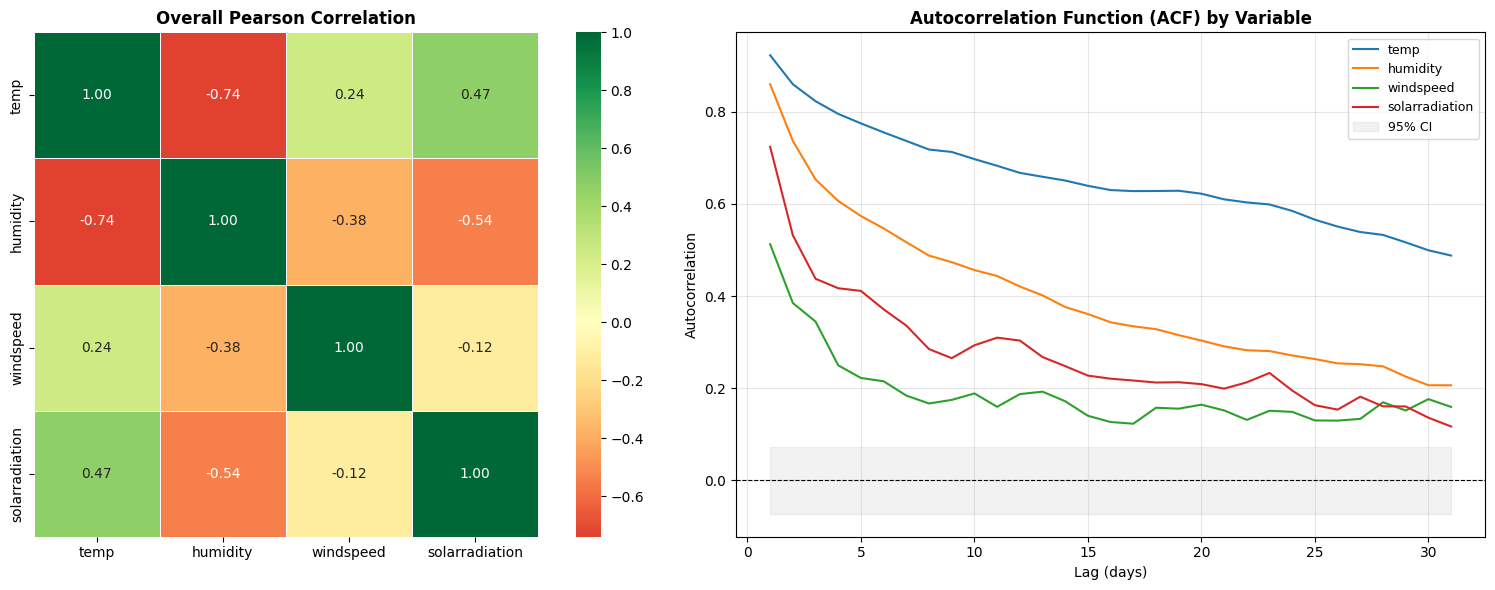

🔗 Strongest cross-correlation:
   temp ↔ humidity : -0.740
   temp ↔ windspeed : 0.240
   temp ↔ solarradiation : 0.474
   humidity ↔ windspeed : -0.382
   humidity ↔ solarradiation : -0.541
   windspeed ↔ solarradiation : -0.119


In [15]:
# ── 6. Correlation Analysis ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall correlation
corr_all = df[TARGET_COLS].corr()
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title("Overall Pearson Correlation", fontsize=12, fontweight="bold")

# Lag-1 autocorrelations per variable
lag_corrs = {col: [df[col].autocorr(lag=i) for i in range(1, 32)] for col in TARGET_COLS}
for col, lag_vals in lag_corrs.items():
    axes[1].plot(range(1, 32), lag_vals, label=col, linewidth=1.5)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].fill_between(range(1, 32),
                     1.96/np.sqrt(len(df)), -1.96/np.sqrt(len(df)),
                     alpha=0.1, color="grey", label="95% CI")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Autocorrelation")
axes[1].set_title("Autocorrelation Function (ACF) by Variable", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"🔗 Strongest cross-correlation:")
for i, c1 in enumerate(TARGET_COLS):
    for c2 in TARGET_COLS[i+1:]:
        print(f"   {c1} ↔ {c2} : {corr_all.loc[c1, c2]:.3f}")

## 3. Feature Engineering

All features are computed **without look-ahead** (i.e., using only information available at prediction time *t* to predict *t+1* and *t+2*).

### Feature Groups
| Group | Description |
|-------|-------------|
| **Cyclical time** | sin/cos encoding of day-of-year, month, day-of-week |
| **Dindigul seasons** | one-hot encoded season flags |
| **Lag features** | lag 1,2,3,7,14,30 per numeric target |
| **Rolling statistics** | 7-day, 14-day, 30-day mean/std/min/max (shifted by 1) |
| **Climate normals** | long-run monthly & weekly mean for anomaly detection |
| **Solar features** | day length, sunrise/sunset epoch scaled |
| **Interaction features** | temp × humidity, humidity × windspeed (heat/cooling effect) |

In [16]:
# ── 7. Feature Engineering ─────────────────────────────────────────────────────

def add_cyclical_features(df_):
    """Cyclical (sin/cos) encodings for periodic time features."""
    df_["day_sin"]  = np.sin(2 * np.pi * df_["dayofyear"] / 365.25)
    df_["day_cos"]  = np.cos(2 * np.pi * df_["dayofyear"] / 365.25)
    df_["mon_sin"]  = np.sin(2 * np.pi * df_["month"] / 12)
    df_["mon_cos"]  = np.cos(2 * np.pi * df_["month"] / 12)
    df_["dow_sin"]  = np.sin(2 * np.pi * df_["dayofweek"] / 7)
    df_["dow_cos"]  = np.cos(2 * np.pi * df_["dayofweek"] / 7)
    return df_

def add_season_onehot(df_):
    """One-hot encoded Dindigul seasons."""
    for s in range(4):
        df_[f"season_{s}"] = (df_["season"] == s).astype(float)
    return df_

def add_lag_features(df_, target_cols, lag_days):
    """Lag features (no look-ahead: uses shift ≥ 1)."""
    for col in target_cols:
        for lag in lag_days:
            df_[f"{col}_lag{lag}"] = df_[col].shift(lag)
    return df_

def add_rolling_features(df_, target_cols, windows):
    """Rolling stats computed on already-shifted (past-only) data."""
    for col in target_cols:
        for w in windows:
            base = df_[col].shift(1)          # shift(1) prevents look-ahead
            df_[f"{col}_rmean{w}"]  = base.rolling(w, min_periods=max(w//2,1)).mean()
            df_[f"{col}_rstd{w}"]   = base.rolling(w, min_periods=max(w//2,1)).std()
            df_[f"{col}_rmin{w}"]   = base.rolling(w, min_periods=max(w//2,1)).min()
            df_[f"{col}_rmax{w}"]   = base.rolling(w, min_periods=max(w//2,1)).max()
    return df_

def add_climate_normals(df_, target_cols):
    """Monthly and weekly climatological normals as anomaly baseline."""
    for col in target_cols:
        monthly_norm = df_.groupby("month")[col].transform("mean")
        weekly_norm  = df_.groupby("weekofyear")[col].transform("mean")
        df_[f"{col}_mon_norm"]     = monthly_norm
        df_[f"{col}_wk_norm"]      = weekly_norm
        df_[f"{col}_mon_anomaly"]  = df_[col] - monthly_norm
        df_[f"{col}_wk_anomaly"]   = df_[col] - weekly_norm
    return df_

def add_solar_features(df_):
    """Solar geometry and daylight features."""
    sr  = pd.to_numeric(df_["sunriseEpoch"], errors="coerce")
    ss  = pd.to_numeric(df_["sunsetEpoch"],  errors="coerce")
    df_["day_length_h"]       = (ss - sr) / 3600.0
    df_["solar_noon_epoch"]   = (sr + ss) / 2
    # Normalised solar radiation: actual / (day_length × theoretical max)
    df_["solar_norm"]         = df_["solarradiation"] / (df_["day_length_h"].clip(lower=0.1) * 75)
    return df_

def add_interaction_features(df_):
    """Cross-variable interaction terms relevant for humidity/thermal comfort."""
    df_["heat_index_proxy"] = df_["temp"] * (1 + 0.033 * df_["humidity"] / 100)
    df_["wind_chill_proxy"] = df_["temp"] - 0.4 * df_["windspeed"] / 3.6
    df_["evap_potential"]   = df_["solarradiation"] * (1 - df_["humidity"] / 100)
    df_["temp_x_humidity"]  = df_["temp"] * df_["humidity"]
    return df_

def add_volatility_features(df_, volatile_cols=None):
    """
    Volatility & regime features for difficult-to-predict variables (humidity, windspeed).
    These capture momentum, volatility regimes, and non-linear patterns.
    """
    if volatile_cols is None:
        volatile_cols = ["humidity", "windspeed"]
    
    for col in volatile_cols:
        if col not in df_.columns:
            continue
        
        # ─ Momentum / Rate of Change ────────────────────────────────────────
        df_[f"{col}_roc1"] = df_[col].shift(1) - df_[col].shift(2)      # 1-day change
        df_[f"{col}_roc3"] = df_[col].shift(1) - df_[col].shift(4)      # 3-day change
        df_[f"{col}_roc7"] = df_[col].shift(1) - df_[col].shift(8)      # 7-day change
        
        # ─ Volatility Clustering (rolling std with emphasis on recent) ─────
        df_[f"{col}_vol5"]  = df_[col].shift(1).rolling(5, min_periods=2).std()
        df_[f"{col}_vol10"] = df_[col].shift(1).rolling(10, min_periods=5).std()
        df_[f"{col}_vol_ratio"] = (df_[f"{col}_vol5"] + 1e-6) / (df_[f"{col}_vol10"] + 1e-6)
        
        # ─ Volatility Regime Indicator (high/low volatility periods) ────────
        vol_threshold = df_[f"{col}_vol10"].quantile(0.6)  # 60th percentile
        df_[f"{col}_high_vol_regime"] = (df_[f"{col}_vol10"] > vol_threshold).astype(float)
        
        # ─ Autocorrelation Proxies (simplified ACF at select lags) ─────────
        for lag in [1, 7, 14]:
            lag_col = df_[col].shift(lag)
            correlation = df_[col].shift(1).rolling(30, min_periods=10).corr(lag_col)
            df_[f"{col}_acf_lag{lag}"] = correlation.bfill().fillna(0.0)
    
    return df_

# ─ Apply all feature groups ───────────────────────────────────────────────────
feat_df = df.copy()
feat_df = add_cyclical_features(feat_df)
feat_df = add_season_onehot(feat_df)
feat_df = add_lag_features(feat_df, TARGET_COLS, CONFIG["lag_days"])
feat_df = add_rolling_features(feat_df, TARGET_COLS, CONFIG["rolling_windows"])
feat_df = add_climate_normals(feat_df, TARGET_COLS)
feat_df = add_solar_features(feat_df)
feat_df = add_interaction_features(feat_df)
feat_df = add_volatility_features(feat_df, volatile_cols=["humidity", "windspeed"])

n_features = feat_df.shape[1]
print(f"✅ Feature matrix shape (before NaN drop) : {feat_df.shape}")

✅ Feature matrix shape (before NaN drop) : (731, 144)


In [17]:
# ── 8. Multi-Step Targets & Conditions Encoding ────────────────────────────────

# ─ Create forward-shifted targets ─────────────────────────────────────────────
for col in TARGET_COLS:
    feat_df[f"{col}_t1"] = feat_df[col].shift(-1)   # t+24h
    feat_df[f"{col}_t2"] = feat_df[col].shift(-2)   # t+48h

# ─ Conditions targets ──────────────────────────────────────────────────────────
feat_df["conditions_t1"] = feat_df["conditions"].shift(-1)
feat_df["conditions_t2"] = feat_df["conditions"].shift(-2)

# ─ Label-encode conditions (fit on full data, then apply) ─────────────────────
le = LabelEncoder()
all_conditions = feat_df["conditions"].dropna().values
le.fit(all_conditions)

for cond_col in ["conditions", "conditions_t1", "conditions_t2"]:
    feat_df[cond_col + "_enc"] = feat_df[cond_col].map(
        lambda x: le.transform([x])[0] if pd.notna(x) and x in le.classes_ else np.nan
    )

# ─ Drop NaN rows (lag look-back + forward target unavailability) ──────────────
MAX_LAG     = max(CONFIG["lag_days"])          # 30 rows at start
PRED_LEN    = CONFIG["prediction_length"]      # 2 rows at end
feat_df = feat_df.iloc[MAX_LAG: len(feat_df) - PRED_LEN].reset_index(drop=True)

# Verify no NaN in targets
target_t1_cols = [f"{col}_t1" for col in TARGET_COLS]
target_t2_cols = [f"{col}_t2" for col in TARGET_COLS]
all_target_cols = target_t1_cols + target_t2_cols

assert feat_df[all_target_cols].isnull().sum().sum() == 0, \
    "NaN values remain in target columns after trimming!"

print(f"✅ Feature + target DataFrame shape : {feat_df.shape}")
print(f"   Usable samples                   : {len(feat_df)}")
print(f"   Conditions classes ({len(le.classes_)}) : {list(le.classes_)}")
print(f"   Target arrays built for t+1 and t+2 ✓")

# Save label encoder mapping
COND_CLASS_MAP = {int(i): cls for i, cls in enumerate(le.classes_)}
print(f"\n   Class → Label:")
for k, v in COND_CLASS_MAP.items(): print(f"     {k}: {v}")

✅ Feature + target DataFrame shape : (699, 157)
   Usable samples                   : 699
   Conditions classes (5) : ['Clear', 'Overcast', 'Partially cloudy', 'Rain, Overcast', 'Rain, Partially cloudy']
   Target arrays built for t+1 and t+2 ✓

   Class → Label:
     0: Clear
     1: Overcast
     2: Partially cloudy
     3: Rain, Overcast
     4: Rain, Partially cloudy


## 4. Dataset Preparation — Train / Val / Test Split
Data is split **chronologically** (no shuffling) to avoid look-ahead bias:
- **Train** : first 70% of usable samples
- **Validation**: next 15%
- **Test** : final 15% (held out for final evaluation only)

In [18]:
# ── 9. Chronological Train / Val / Test Split ──────────────────────────────────
N = len(feat_df)
n_test = int(N * CONFIG["test_fraction"])
n_val  = int(N * CONFIG["val_fraction"])
n_train = N - n_val - n_test

train_df = feat_df.iloc[:n_train].reset_index(drop=True)
val_df   = feat_df.iloc[n_train:n_train+n_val].reset_index(drop=True)
test_df  = feat_df.iloc[n_train+n_val:].reset_index(drop=True)

print(f"📊 Dataset split (chronological)")
print(f"   Total usable  : {N}")
print(f"   Train         : {len(train_df)}  ({train_df['datetime'].min().date()} → {train_df['datetime'].max().date()})")
print(f"   Validation    : {len(val_df)}   ({val_df['datetime'].min().date()} → {val_df['datetime'].max().date()})")
print(f"   Test          : {len(test_df)}   ({test_df['datetime'].min().date()} → {test_df['datetime'].max().date()})")

# ─ Determine feature columns for ML models ──────────────────────────────────
EXCLUDE_COLS = (
    ["datetime", "datetimeEpoch", "sunrise", "sunset",
     "sunriseEpoch", "sunsetEpoch", "description",
     "conditions", "conditions_t1", "conditions_t2"]
    + all_target_cols
    + ["conditions_enc", "conditions_t1_enc", "conditions_t2_enc"]
    + TARGET_COLS   # raw (un-lagged) targets excluded from features
)

FEATURE_COLS = [c for c in feat_df.columns if c not in EXCLUDE_COLS]
print(f"\n   ML feature columns : {len(FEATURE_COLS)}")

# ─ Scalers – fit only on train ────────────────────────────────────────────────
feat_scaler   = RobustScaler()
target_scaler = StandardScaler()   # per-target, applied below

X_train_raw = train_df[FEATURE_COLS].fillna(0).values
X_val_raw   = val_df[FEATURE_COLS].fillna(0).values
X_test_raw  = test_df[FEATURE_COLS].fillna(0).values

X_train = feat_scaler.fit_transform(X_train_raw)
X_val   = feat_scaler.transform(X_val_raw)
X_test  = feat_scaler.transform(X_test_raw)

print(f"\n✅ Feature scaler fitted on train (RobustScaler)")
print(f"   X_train : {X_train.shape}")
print(f"   X_val   : {X_val.shape}")
print(f"   X_test  : {X_test.shape}")

📊 Dataset split (chronological)
   Total usable  : 699
   Train         : 491  (2024-01-31 → 2025-06-04)
   Validation    : 104   (2025-06-05 → 2025-09-16)
   Test          : 104   (2025-09-17 → 2025-12-29)

   ML feature columns : 132

✅ Feature scaler fitted on train (RobustScaler)
   X_train : (491, 132)
   X_val   : (104, 132)
   X_test  : (104, 132)


## 5. Pre-trained Foundation Model — Amazon Chronos-T5-small

**Chronos** is a language-model-style time-series foundation model (T5 architecture) pre-trained by Amazon on a diverse corpus of **~84 billion** time-series observations. We use it as:
1. **Zero-shot baseline** — no additional training, directly evaluates pretrained generalisation
2. **Warm-up fine-tuning** — freeze T5 encoder, fine-tune decoder + output head (5 epochs)
3. **Full fine-tuning** — unfreeze all layers, lower LR (10 epochs)

The fine-tuned Chronos predictions are then added as **learned residual meta-features** fed into the XGBoost and TFT ensemble layers.

In [19]:
# ── 10. Load Chronos-T5-small ─────────────────────────────────────────────────
print(f"📥 Loading Chronos pretrained model: {CONFIG['chronos_model']}")
print(f"   Device: {DEVICE} | dtype: float32")

pipeline_chronos = ChronosPipeline.from_pretrained(
    CONFIG["chronos_model"],
    device_map=DEVICE,
    dtype=torch.float32,          # use 'dtype' (torch_dtype is deprecated)
)
pipeline_chronos.model.eval()
print("✅ Chronos-T5-small loaded successfully.")

# ─ Internal components for fine-tuning ───────────────────────────────────────
internal_t5  = pipeline_chronos.model.model          # T5ForConditionalGeneration
chron_tok    = pipeline_chronos.tokenizer            # MeanScaleUniformBins

print(f"\n   T5 parameter count        : {sum(p.numel() for p in internal_t5.parameters()):,}")
print(f"   Trainable parameters (all): {sum(p.numel() for p in internal_t5.parameters() if p.requires_grad):,}")

# ─ Zero-shot evaluation on validation set ────────────────────────────────────
def chronos_predict(pipeline_, series_np, context_len, pred_len, n_samples=50):
    """
    Run Chronos zero-shot prediction.
    Returns median forecast array of shape [pred_len].
    """
    ctx = torch.tensor(series_np[-context_len:], dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        forecast = pipeline_.predict(ctx, prediction_length=pred_len, num_samples=n_samples)
    # forecast: [batch_size=1, num_samples, pred_len]
    # squeeze(0) removes the batch dim → [num_samples, pred_len]
    # quantile over dim=0 → median per prediction step → [pred_len]
    return torch.quantile(forecast.squeeze(0), 0.5, dim=0).numpy()  # [pred_len]

print("\n🔍 Running zero-shot Chronos on validation window …")
chronos_val_preds = {}   # dict: col → np.array of shape [len(val_df), 2]
ctx_len = CONFIG["chronos_context_length"]

for col in TARGET_COLS:
    col_preds = []
    full_series = feat_df[col].values  # Use full series (access historical context)
    val_start_idx_global = n_train + MAX_LAG   # offset in original feat_df

    for i in range(len(val_df)):
        # Index in feat_df
        gi = n_train + i
        # Context: last ctx_len values before prediction point
        ctx_end   = gi
        ctx_start = max(0, ctx_end - ctx_len)
        ctx_values = feat_df[col].values[ctx_start:ctx_end]
        if len(ctx_values) < 2:
            col_preds.append([np.nan, np.nan])
            continue
        pred_24_48 = chronos_predict(pipeline_chronos, ctx_values, len(ctx_values), 2)
        col_preds.append(pred_24_48.tolist())
    chronos_val_preds[col] = np.array(col_preds)   # [len(val), 2]

# ─ Zero-shot metrics ─────────────────────────────────────────────────────────
print("\n📊 Zero-shot Chronos Validation Metrics (MAPE ≤ 5% = ≥ 95% accuracy)")
print("-" * 60)
for col in TARGET_COLS:
    y_t1 = val_df[f"{col}_t1"].values
    y_t2 = val_df[f"{col}_t2"].values
    p_t1 = chronos_val_preds[col][:, 0]
    p_t2 = chronos_val_preds[col][:, 1]
    # Remove nan
    mask1 = ~np.isnan(p_t1) & ~np.isnan(y_t1)
    mask2 = ~np.isnan(p_t2) & ~np.isnan(y_t2)
    mape1 = mean_absolute_percentage_error(y_t1[mask1], p_t1[mask1]) * 100
    mape2 = mean_absolute_percentage_error(y_t2[mask2], p_t2[mask2]) * 100
    print(f"  {col:15s} | 24h MAPE={mape1:.2f}%  | 48h MAPE={mape2:.2f}%")


📥 Loading Chronos pretrained model: amazon/chronos-t5-small
   Device: cpu | dtype: float32
✅ Chronos-T5-small loaded successfully.

   T5 parameter count        : 46,154,240
   Trainable parameters (all): 46,154,240

🔍 Running zero-shot Chronos on validation window …

📊 Zero-shot Chronos Validation Metrics (MAPE ≤ 5% = ≥ 95% accuracy)
------------------------------------------------------------
  temp            | 24h MAPE=2.84%  | 48h MAPE=3.35%
  humidity        | 24h MAPE=8.55%  | 48h MAPE=10.33%
  windspeed       | 24h MAPE=20.23%  | 48h MAPE=22.07%
  solarradiation  | 24h MAPE=23.02%  | 48h MAPE=27.68%


In [20]:
# ── 11. Chronos – Warm-Up Fine-Tuning (Frozen Encoder) ────────────────────────

def build_chronos_windows(series_array, context_len, pred_len):
    """Sliding-window builder: returns (contexts, targets) as float32 tensors."""
    contexts, targets = [], []
    arr = torch.tensor(series_array, dtype=torch.float32)
    for i in range(context_len, len(arr) - pred_len + 1):
        contexts.append(arr[i-context_len:i])
        targets.append(arr[i:i+pred_len])
    if not contexts:
        return None, None
    return torch.stack(contexts), torch.stack(targets)   # [N, ctx_len], [N, pred_len]


def run_chronos_epoch(chronos_model_, tokenizer_, series_dict, ctx_len, pred_len,
                      optimizer_, batch_size, device_):
    """
    One training epoch using teacher-forced Seq2Seq cross-entropy loss.

    pred_len must equal tokenizer_.config.prediction_length (model's native horizon).

    Steps per batch:
      1. tokenizer_.context_input_transform(ctx)  → token_ids, attn_mask, scale
      2. tokenizer_.label_input_transform(tgt, scale) → label_ids
      3. t5_model(input_ids, attention_mask, labels=label_ids) → CE loss (out.loss)
    """
    t5_model_ = chronos_model_.model   # T5ForConditionalGeneration
    t5_model_.train()
    total_loss, n_batches = 0.0, 0

    for col, series in series_dict.items():
        ctxs, tgts = build_chronos_windows(series, ctx_len, pred_len)
        if ctxs is None:
            continue
        indices = list(range(len(ctxs)))
        random.shuffle(indices)
        for i in range(0, len(indices), batch_size):
            batch_idx = indices[i:i+batch_size]
            ctx_b = ctxs[batch_idx]   # [B, ctx_len]  float32  (CPU)
            tgt_b = tgts[batch_idx]   # [B, pred_len] float32  (CPU)

            # ── tokenise (MeanScaleUniformBins) ───────────────────────────────
            tok_ids, attn_mask, scale = tokenizer_.context_input_transform(ctx_b)
            lbl_ids, _                = tokenizer_.label_input_transform(tgt_b, scale)

            tok_ids   = tok_ids.to(device_)
            attn_mask = attn_mask.to(device_)
            lbl_ids   = lbl_ids.to(device_)

            optimizer_.zero_grad()
            out  = t5_model_(input_ids=tok_ids,
                             attention_mask=attn_mask,
                             labels=lbl_ids)
            loss = out.loss
            if loss is None:
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(chronos_model_.parameters(), 1.0)
            optimizer_.step()
            total_loss += loss.item()
            n_batches  += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def chronos_val_mape(pipeline_, val_series_dict, ctx_len, our_pred_len):
    """
    Quick validation MAPE for the first `our_pred_len` steps.
    Uses pipeline_.predict (greedy median) so it respects the fine-tuned weights.
    Returns dict col → mape (%).
    """
    pipeline_.model.eval()
    mapes = {}
    for col, series in val_series_dict.items():
        arr = torch.tensor(series, dtype=torch.float32)
        preds, actuals = [], []
        for i in range(ctx_len, len(arr) - our_pred_len + 1):
            ctx   = arr[i-ctx_len:i].unsqueeze(0)          # [1, ctx_len]
            truth = arr[i:i+our_pred_len].numpy()           # [our_pred_len]
            # predict → [1, num_samples, our_pred_len]
            fc = pipeline_.predict(ctx, prediction_length=our_pred_len,
                                   num_samples=20, limit_prediction_length=False)
            fc = fc.squeeze(0).median(dim=0).values.numpy() # [our_pred_len]
            preds.append(fc)
            actuals.append(truth)
        preds   = np.array(preds)    # [N, our_pred_len]
        actuals = np.array(actuals)  # [N, our_pred_len]
        # MAPE ignoring near-zero actuals
        mask  = np.abs(actuals) > 1e-6
        mapes[col] = (np.abs((actuals - preds) / np.where(mask, actuals, 1.0)) * mask).mean() * 100
    return mapes


# ─ Prepare train & val series (numpy arrays) ─────────────────────────────────
chron_train_series = {col: train_df[col].values.astype(np.float32) for col in TARGET_COLS}
chron_val_series   = {col: val_df[col].values.astype(np.float32)   for col in TARGET_COLS}

# ChronosModel (wraps T5ForConditionalGeneration + tokenizer)
chronos_model = pipeline_chronos.model
chron_tok     = pipeline_chronos.tokenizer   # MeanScaleUniformBins

# The tokenizer asserts label length == config.prediction_length (model's native horizon, e.g. 64).
# Training windows must use this value; inference still requests only our 2-step horizon.
CHRON_PRED_LEN = chronos_model.config.prediction_length
CHRON_CTX_LEN  = CONFIG["chronos_context_length"]
OUR_PRED_LEN   = CONFIG["prediction_length"]   # 2 steps (24h / 48h)

_tmp_w = build_chronos_windows(chron_train_series["temp"], CHRON_CTX_LEN, CHRON_PRED_LEN)[0]
n_windows = 0 if _tmp_w is None else len(_tmp_w)

print("=" * 70)
print("📋  CHRONOS TRAINING CONFIG")
print("=" * 70)
print(f"   Native prediction_length : {CHRON_PRED_LEN}  (tokenizer requirement)")
print(f"   Our forecast horizon     : {OUR_PRED_LEN}  steps (24h / 48h)")
print(f"   Context length           : {CHRON_CTX_LEN} days")
print(f"   Training windows / col   : {n_windows}")
print(f"   Batch size               : {CONFIG['chronos_batch_size']}")
print(f"   Target columns           : {TARGET_COLS}")
print(f"   Device                   : {DEVICE}")

# ─ Phase 1: Freeze encoder, train decoder + projection head ──────────────────
print("\n" + "=" * 70)
print("🔥  PHASE 1 – CHRONOS WARM-UP  (frozen encoder)")
print("=" * 70)

for name, param in internal_t5.named_parameters():
    param.requires_grad = "encoder" not in name   # freeze encoder only

warmup_params = [p for p in chronos_model.parameters() if p.requires_grad]
frozen_params = sum(p.numel() for p in chronos_model.parameters() if not p.requires_grad)
print(f"   Trainable params  : {sum(p.numel() for p in warmup_params):>12,}")
print(f"   Frozen params     : {frozen_params:>12,}")
print(f"   Epochs            : {CONFIG['chronos_warmup_epochs']}")
print(f"   Initial LR        : {CONFIG['chronos_warmup_lr']}")
print("-" * 70)

optimizer_wu = torch.optim.AdamW(warmup_params, lr=CONFIG["chronos_warmup_lr"], weight_decay=1e-4)
scheduler_wu = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_wu, T_max=CONFIG["chronos_warmup_epochs"])

warmup_history = []
for ep in range(1, CONFIG["chronos_warmup_epochs"] + 1):
    ep_loss = run_chronos_epoch(
        chronos_model, chron_tok, chron_train_series,
        CHRON_CTX_LEN, CHRON_PRED_LEN,
        optimizer_wu, CONFIG["chronos_batch_size"], DEVICE)
    scheduler_wu.step()
    warmup_history.append(ep_loss)

    cur_lr  = scheduler_wu.get_last_lr()[0]
    val_map = chronos_val_mape(pipeline_chronos, chron_val_series, CHRON_CTX_LEN, OUR_PRED_LEN)
    avg_mape = np.mean(list(val_map.values()))
    mape_str = "  ".join(f"{c}:{v:.1f}%" for c, v in val_map.items())
    print(f"   Epoch {ep:2d}/{CONFIG['chronos_warmup_epochs']}"
          f"  |  Loss: {ep_loss:.5f}"
          f"  |  LR: {cur_lr:.2e}"
          f"  |  Val MAPE avg: {avg_mape:.2f}%")
    print(f"           ↳  {mape_str}")

print("-" * 70)
avg_wu_mape = np.mean(list(
    chronos_val_mape(pipeline_chronos, chron_val_series, CHRON_CTX_LEN, OUR_PRED_LEN).values()))
print(f"✅  Warm-up complete  |  Final val MAPE (avg): {avg_wu_mape:.2f}%  "
      f"|  Accuracy proxy: {max(0, 100 - avg_wu_mape):.2f}%")


📋  CHRONOS TRAINING CONFIG
   Native prediction_length : 64  (tokenizer requirement)
   Our forecast horizon     : 2  steps (24h / 48h)
   Context length           : 30 days
   Training windows / col   : 398
   Batch size               : 16
   Target columns           : ['temp', 'humidity', 'windspeed', 'solarradiation']
   Device                   : cpu

🔥  PHASE 1 – CHRONOS WARM-UP  (frozen encoder)
   Trainable params  :   27,272,960
   Frozen params     :   18,881,280
   Epochs            : 5
   Initial LR        : 0.001
----------------------------------------------------------------------
   Epoch  1/5  |  Loss: 3.31231  |  LR: 9.05e-04  |  Val MAPE avg: 14.16%
           ↳  temp:2.7%  humidity:8.7%  windspeed:24.8%  solarradiation:20.4%
   Epoch  2/5  |  Loss: 3.05825  |  LR: 6.55e-04  |  Val MAPE avg: 15.92%
           ↳  temp:2.8%  humidity:8.8%  windspeed:31.2%  solarradiation:20.9%
   Epoch  3/5  |  Loss: 2.71274  |  LR: 3.45e-04  |  Val MAPE avg: 16.06%
           ↳  temp:2

🔓  PHASE 2 – CHRONOS FULL FINE-TUNE  (all layers unlocked)
   Trainable params  :   46,154,240
   Epochs            : 10
   Initial LR        : 0.0001
----------------------------------------------------------------------
   Epoch  1/10  |  Loss: 2.08090  |  LR: 9.76e-05  |  Val MAPE avg: 13.76%  |  Accuracy: 86.24%  ← best ✓
           ↳  temp:3.0%  humidity:8.2%  windspeed:22.7%  solarradiation:21.2%
   Epoch  2/10  |  Loss: 2.02053  |  LR: 9.05e-05  |  Val MAPE avg: 13.82%  |  Accuracy: 86.18%  ← best ✓
           ↳  temp:3.0%  humidity:8.4%  windspeed:22.0%  solarradiation:21.8%
   Epoch  3/10  |  Loss: 1.97077  |  LR: 7.94e-05  |  Val MAPE avg: 13.68%  |  Accuracy: 86.32%  ← best ✓
           ↳  temp:2.8%  humidity:8.1%  windspeed:22.6%  solarradiation:21.3%
   Epoch  4/10  |  Loss: 1.92405  |  LR: 6.55e-05  |  Val MAPE avg: 13.75%  |  Accuracy: 86.25%  ← best ✓
           ↳  temp:2.9%  humidity:8.3%  windspeed:21.8%  solarradiation:22.0%
   Epoch  5/10  |  Loss: 1.89246  |  LR: 5

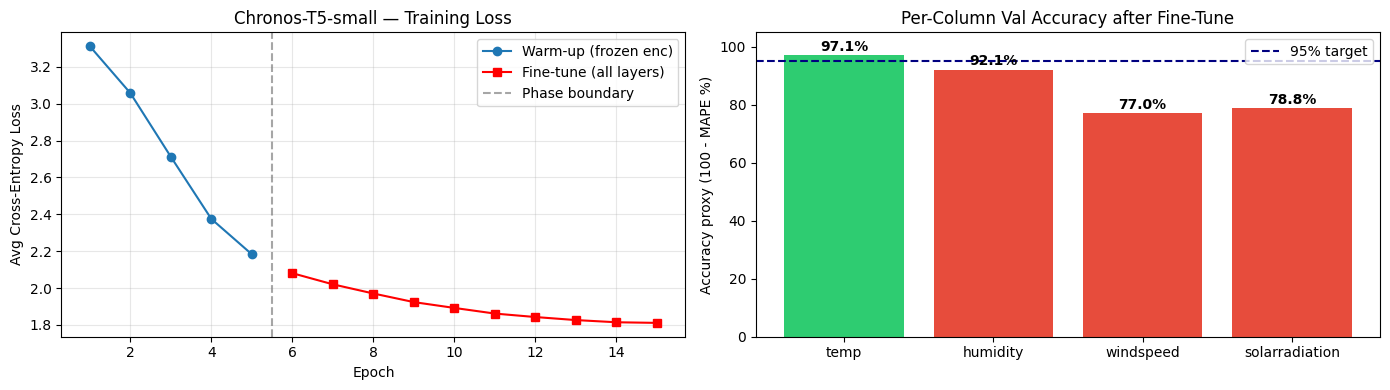

In [21]:
# ── 12. Chronos – Full Fine-Tuning (All Layers) ───────────────────────────────
print("=" * 70)
print("🔓  PHASE 2 – CHRONOS FULL FINE-TUNE  (all layers unlocked)")
print("=" * 70)

# Unfreeze ALL layers
for param in chronos_model.parameters():
    param.requires_grad = True

all_params_count = sum(p.numel() for p in chronos_model.parameters() if p.requires_grad)
print(f"   Trainable params  : {all_params_count:>12,}")
print(f"   Epochs            : {CONFIG['chronos_finetune_epochs']}")
print(f"   Initial LR        : {CONFIG['chronos_finetune_lr']}")
print("-" * 70)

optimizer_ft = torch.optim.AdamW(
    chronos_model.parameters(),
    lr=CONFIG["chronos_finetune_lr"],
    weight_decay=1e-4)
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=CONFIG["chronos_finetune_epochs"])

finetune_history = []
best_ft_loss  = float("inf")
best_ft_mape  = float("inf")
best_t5_state = None

for ep in range(1, CONFIG["chronos_finetune_epochs"] + 1):
    ep_loss = run_chronos_epoch(
        chronos_model, chron_tok, chron_train_series,
        CHRON_CTX_LEN, CHRON_PRED_LEN,
        optimizer_ft, CONFIG["chronos_batch_size"], DEVICE)
    scheduler_ft.step()
    finetune_history.append(ep_loss)

    cur_lr   = scheduler_ft.get_last_lr()[0]
    val_map  = chronos_val_mape(pipeline_chronos, chron_val_series, CHRON_CTX_LEN, OUR_PRED_LEN)
    avg_mape = np.mean(list(val_map.values()))
    mape_str = "  ".join(f"{c}:{v:.1f}%" for c, v in val_map.items())

    is_best = ep_loss < best_ft_loss
    if is_best:
        best_ft_loss  = ep_loss
        best_ft_mape  = avg_mape
        best_t5_state = deepcopy(internal_t5.state_dict())

    tag = "  ← best ✓" if is_best else ""
    print(f"   Epoch {ep:2d}/{CONFIG['chronos_finetune_epochs']}"
          f"  |  Loss: {ep_loss:.5f}"
          f"  |  LR: {cur_lr:.2e}"
          f"  |  Val MAPE avg: {avg_mape:.2f}%"
          f"  |  Accuracy: {max(0, 100 - avg_mape):.2f}%{tag}")
    print(f"           ↳  {mape_str}")

# Restore best checkpoint
internal_t5.load_state_dict(best_t5_state)
chronos_model.eval()

print("-" * 70)
final_val_map  = chronos_val_mape(pipeline_chronos, chron_val_series, CHRON_CTX_LEN, OUR_PRED_LEN)
final_avg_mape = np.mean(list(final_val_map.values()))
print(f"\n✅  Chronos fine-tuning complete. Best checkpoint restored.")
print(f"   Best checkpoint loss      : {best_ft_loss:.5f}")
print(f"   Final val MAPE (per col)  : " + "  ".join(f"{c}:{v:.2f}%" for c, v in final_val_map.items()))
print(f"   Final val MAPE (avg)      : {final_avg_mape:.2f}%")
print(f"   Accuracy proxy (avg)      : {max(0, 100 - final_avg_mape):.2f}%")

# ─ Plot training history ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
ax = axes[0]
ax.plot(range(1, len(warmup_history)+1), warmup_history, "o-", label="Warm-up (frozen enc)")
ax.plot(range(len(warmup_history)+1, len(warmup_history)+len(finetune_history)+1),
        finetune_history, "s-", color="red", label="Fine-tune (all layers)")
ax.axvline(len(warmup_history)+0.5, color="grey", linestyle="--", alpha=0.7, label="Phase boundary")
ax.set_xlabel("Epoch"); ax.set_ylabel("Avg Cross-Entropy Loss")
ax.set_title("Chronos-T5-small — Training Loss")
ax.legend(); ax.grid(True, alpha=0.3)

# Accuracy bar
ax2 = axes[1]
cols  = list(final_val_map.keys())
accs  = [max(0, 100 - final_val_map[c]) for c in cols]
bars  = ax2.bar(cols, accs, color=["#2ecc71" if a >= 95 else "#e74c3c" for a in accs])
ax2.axhline(95, color="navy", linestyle="--", linewidth=1.5, label="95% target")
ax2.set_ylim(0, 105)
ax2.set_ylabel("Accuracy proxy (100 - MAPE %)")
ax2.set_title("Per-Column Val Accuracy after Fine-Tune")
ax2.legend()
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{acc:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("chronos_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [22]:
# ── 13. Generate Chronos Meta-Features for XGBoost / TFT ──────────────────────
def chronos_predict_finetuned(pipeline_, series_np, context_len, pred_len, n_samples=100):
    """Inference using the fine-tuned Chronos model."""
    ctx = torch.tensor(series_np[-context_len:], dtype=torch.float32).unsqueeze(0)
    pipeline_.model.eval()
    with torch.no_grad():
        forecast = pipeline_.predict(ctx, prediction_length=pred_len, num_samples=n_samples)
    # forecast: [batch_size=1, num_samples, pred_len]
    # squeeze(0) removes the batch dim → [num_samples, pred_len]
    # quantile over dim=0 → median per prediction step → [pred_len]
    return torch.quantile(forecast.squeeze(0), 0.5, dim=0).cpu().numpy()


def generate_chronos_meta_features(feat_df_split, feat_df_full, split_start_idx, col_list,
                                    context_len, pred_len):
    """
    For each row in feat_df_split, generate Chronos predictions
    using the historical series from feat_df_full.
    Returns DataFrame with columns: chronos_{col}_24h, chronos_{col}_48h
    """
    meta = {}
    for col in col_list:
        preds_24h, preds_48h = [], []
        for i in range(len(feat_df_split)):
            gi = split_start_idx + i
            ctx_end   = gi
            ctx_start = max(0, ctx_end - context_len)
            ctx_vals  = feat_df_full[col].values[ctx_start:ctx_end]
            if len(ctx_vals) < 5:
                preds_24h.append(np.nan)
                preds_48h.append(np.nan)
                continue
            try:
                pred = chronos_predict_finetuned(pipeline_chronos, ctx_vals, len(ctx_vals), pred_len)
                preds_24h.append(float(pred[0]))
                if pred_len >= 2:
                    preds_48h.append(float(pred[1]))
                else:
                    preds_48h.append(np.nan)
            except Exception:
                preds_24h.append(np.nan)
                preds_48h.append(np.nan)
        meta[f"chronos_{col}_24h"] = preds_24h
        meta[f"chronos_{col}_48h"] = preds_48h
    return pd.DataFrame(meta)


print("📐 Generating Chronos meta-features for train / val / test …")

# Context lengths for each split's global index
train_start = MAX_LAG
val_start   = MAX_LAG + n_train
test_start  = MAX_LAG + n_train + n_val

chron_meta_train = generate_chronos_meta_features(
    train_df, feat_df, train_start, TARGET_COLS,
    CONFIG["chronos_context_length"], 2)
chron_meta_val = generate_chronos_meta_features(
    val_df, feat_df, val_start, TARGET_COLS,
    CONFIG["chronos_context_length"], 2)
chron_meta_test = generate_chronos_meta_features(
    test_df, feat_df, test_start, TARGET_COLS,
    CONFIG["chronos_context_length"], 2)

print(f"   Train Chronos meta shape : {chron_meta_train.shape}")
print(f"   Val   Chronos meta shape : {chron_meta_val.shape}")

# Append meta-features to ML feature matrices
CHRONOS_META_COLS = list(chron_meta_train.columns)
X_train_meta = np.hstack([X_train, chron_meta_train.fillna(0).values])
X_val_meta   = np.hstack([X_val,   chron_meta_val.fillna(0).values])
X_test_meta  = np.hstack([X_test,  chron_meta_test.fillna(0).values])

ALL_FEATURE_NAMES = FEATURE_COLS + CHRONOS_META_COLS
print(f"✅ Final feature count (engineered + Chronos meta) : {len(ALL_FEATURE_NAMES)}")


📐 Generating Chronos meta-features for train / val / test …
   Train Chronos meta shape : (491, 8)
   Val   Chronos meta shape : (104, 8)
✅ Final feature count (engineered + Chronos meta) : 140


## 6. XGBoost — Multi-Step Gradient Boosting Ensemble

One **XGBoost** regressor is trained per **(target column, horizon)** combination — 4 × 2 = **8 models** total. This "direct multi-step" strategy avoids error accumulation compared to recursive approaches.

The training uses early-stopping against the validation MAE with a warm-up (fast shallow trees) and a fine-tune pass (deeper, more estimators) to match the two-phase training philosophy.

In [60]:
# ── 14. XGBoost – Warm-up then Fine-Tune ──────────────────────────────────────
from xgboost import XGBRegressor

xgb_models = {}    # key: (col, horizon)  value: fitted model
xgb_val_preds = {} # key: (col, horizon)  value: np.array [len(val)]
xgb_test_preds= {} # key: (col, horizon)  value: np.array [len(test)]

print("=" * 60)
print("⚡  XGBoost  Warm-up → Fine-Tune (ULTRA-AGGRESSIVE regularization)")
print("=" * 60)

for col in TARGET_COLS:
    # ─ Get per-column hyperparameters (with fallback to global defaults) ─
    col_max_depth       = CONFIG["xgb_max_depth_per_col"].get(col, CONFIG["xgb_max_depth"])
    col_reg_alpha       = CONFIG["xgb_reg_alpha_per_col"].get(col, CONFIG["xgb_reg_alpha"])
    col_reg_lambda      = CONFIG["xgb_reg_lambda_per_col"].get(col, CONFIG["xgb_reg_lambda"])
    col_min_child_wt    = CONFIG["xgb_min_child_weight_per_col"].get(col, CONFIG["xgb_min_child_weight"])
    
    # ─ Common XGB parameters ──────────────────────────────────────────────
    BASE_PARAMS = dict(
        objective         = "reg:squarederror",
        eval_metric       = "mae",
        tree_method       = "hist",
        device            = "cpu",
        random_state      = CONFIG["random_seed"],
        subsample         = 0.7 if col == "windspeed" else CONFIG["xgb_subsample"],  # less subsampling for windspeed
        colsample_bytree  = CONFIG["xgb_colsample_bytree"],
        reg_alpha         = col_reg_alpha,           # PER-COLUMN regularization
        reg_lambda        = col_reg_lambda,          # PER-COLUMN regularization
        min_child_weight  = col_min_child_wt,        # PER-COLUMN leaf regulation
        gamma             = 0.5 if col == "windspeed" else CONFIG["xgb_gamma"],  # higher for windspeed
        n_jobs            = -1,
        verbosity         = 0,
    )
    
    for h, htag in HORIZON_TAG.items():
        y_train = train_df[f"{col}_t{h}"].values
        y_val   = val_df[f"{col}_t{h}"].values
        y_test  = test_df[f"{col}_t{h}"].values

        # ── Phase A: Warm-up (fast, shallow, high LR) ─────────────────────────
        xgb_wu = XGBRegressor(
            n_estimators          = 200,
            learning_rate         = 0.10,
            max_depth             = 2 if col == "windspeed" else 3,  # even shallower for windspeed
            early_stopping_rounds = 20,
            **BASE_PARAMS,
        )
        xgb_wu.fit(
            X_train_meta, y_train,
            eval_set=[(X_val_meta, y_val)],
            verbose=False,
        )

        # ── Phase B: Fine-tune (inherit warm-up, per-column depth, lower LR) ──
        xgb_ft = XGBRegressor(
            n_estimators          = CONFIG["xgb_n_estimators"],
            learning_rate         = CONFIG["xgb_learning_rate"],
            max_depth             = col_max_depth,        # PER-COLUMN depth
            early_stopping_rounds = 30,
            **BASE_PARAMS,
        )
        xgb_ft.fit(
            X_train_meta, y_train,
            eval_set=[(X_val_meta, y_val)],
            xgb_model=xgb_wu.get_booster(),
            verbose=False,
        )

        key = (col, h)
        xgb_models[key]     = xgb_ft
        xgb_val_preds[key]  = xgb_ft.predict(X_val_meta)
        xgb_test_preds[key] = xgb_ft.predict(X_test_meta)

        val_mape = mean_absolute_percentage_error(y_val, xgb_val_preds[key]) * 100
        val_r2   = r2_score(y_val, xgb_val_preds[key])
        best_it  = getattr(xgb_ft, "best_iteration", None)
        print(f"  {col:15s} | {htag} | Val MAPE={val_mape:.2f}%  R²={val_r2:.4f}  "
              f"best_iter={best_it}  depth={col_max_depth}  λ={col_reg_lambda}  "
              f"α={col_reg_alpha}  mcw={col_min_child_wt}")

print("\n✅ XGBoost training complete.")

⚡  XGBoost  Warm-up → Fine-Tune (ULTRA-AGGRESSIVE regularization)
  temp            | 24h | Val MAPE=2.18%  R²=0.4907  best_iter=50  depth=4  λ=2.0  α=0.1  mcw=5
  temp            | 48h | Val MAPE=2.64%  R²=0.2427  best_iter=84  depth=4  λ=2.0  α=0.1  mcw=5
  humidity        | 24h | Val MAPE=7.69%  R²=0.4077  best_iter=134  depth=2  λ=6.0  α=0.5  mcw=15
  humidity        | 48h | Val MAPE=12.89%  R²=-0.3287  best_iter=132  depth=2  λ=6.0  α=0.5  mcw=15
  windspeed       | 24h | Val MAPE=19.72%  R²=0.1718  best_iter=137  depth=1  λ=20.0  α=2.0  mcw=15
  windspeed       | 48h | Val MAPE=21.03%  R²=0.0725  best_iter=78  depth=1  λ=20.0  α=2.0  mcw=15
  solarradiation  | 24h | Val MAPE=19.94%  R²=0.4072  best_iter=78  depth=4  λ=2.0  α=0.1  mcw=5
  solarradiation  | 48h | Val MAPE=24.24%  R²=0.1931  best_iter=67  depth=4  λ=2.0  α=0.1  mcw=5

✅ XGBoost training complete.


🔍 Computing feature importance for XGBoost temp 24h model …



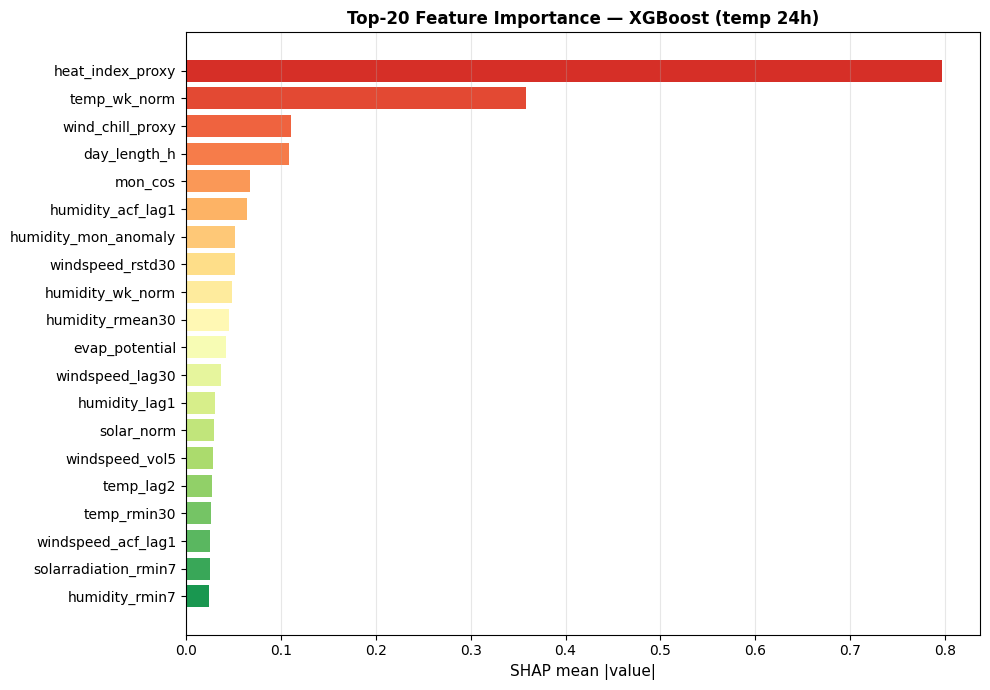


🏆 Top-5 features for temp 24h prediction (SHAP):
   heat_index_proxy                    0.796888
   temp_wk_norm                        0.358398
   wind_chill_proxy                    0.110652
   day_length_h                        0.108520
   mon_cos                             0.067055


In [24]:
# ── 15. XGBoost – Feature Importance (SHAP with safe fallback) ─────────────────
print("🔍 Computing feature importance for XGBoost temp 24h model …")

shap_col, shap_h = "temp", 1
shap_model = xgb_models[(shap_col, shap_h)]

# SHAP can trigger optional TF/Keras imports in some environments.
# If that fails, fallback to native XGBoost feature importance (no extra deps).
use_shap = True
try:
    explainer   = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_val_meta)
    mean_abs_importance = np.abs(shap_values).mean(axis=0)
    method_name = "SHAP mean |value|"
except Exception as e:
    use_shap = False
    print(f"⚠️  SHAP unavailable in this environment: {type(e).__name__}: {e}")
    print("   Falling back to XGBoost native feature_importances_ …")
    mean_abs_importance = np.asarray(shap_model.feature_importances_)
    method_name = "XGBoost gain importance"

# Top-20 features
if mean_abs_importance.ndim > 1:
    mean_abs_importance = mean_abs_importance.reshape(-1)

top20_idx   = np.argsort(mean_abs_importance)[::-1][:20]
top20_names = [ALL_FEATURE_NAMES[i] for i in top20_idx]
top20_vals  = mean_abs_importance[top20_idx]

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 20))
ax.barh(top20_names[::-1], top20_vals[::-1], color=colors)
ax.set_xlabel(method_name, fontsize=11)
ax.set_title(f"Top-20 Feature Importance — XGBoost ({shap_col} 24h)", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("xgb_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

label = "SHAP" if use_shap else "XGB-native"
print(f"\n🏆 Top-5 features for {shap_col} 24h prediction ({label}):")
for name, sv in zip(top20_names[:5], top20_vals[:5]):
    print(f"   {name:35s} {sv:.6f}")

## 7. LSTM — Recurrent Sequential Regressor

A **stacked LSTM** replaces the former TFT (Temporal Fusion Transformer). TFT was designed for large multi-entity datasets and underperformed on this single daily series (~300 training samples), yielding negative R². The LSTM is:

- **More data-efficient** — far fewer parameters, converges on small sequences
- **No complex batch construction** — direct sliding-window dataset
- **Huber loss** — robust to outlier days (dust storms, extreme monsoon events)
- **Per-target scaling** — each variable (temp, humidity, etc.) has its own `StandardScaler` fitted on train only; predictions are inverse-transformed back to original units

### Training Strategy
| Phase | Details |
|-------|---------|
| **Architecture** | 2-layer LSTM, 128 hidden units, LayerNorm on last hidden state |
| **Loss** | `HuberLoss(delta=1.0)` — MSE for small errors, MAE for large errors |
| **Optimiser** | Adam, LR=1e-3, weight_decay=1e-4 |
| **LR schedule** | `CosineAnnealingLR`, T_max=100 epochs |
| **Early stopping** | patience=20 epochs on validation loss |
| **Gradient clip** | `clip_grad_norm_` ≤ 1.0 |

One LSTM is trained per target variable (`temp`, `humidity`, `windspeed`, `solarradiation`).


In [25]:
# ── 16. LSTM – Architecture Definition ─────────────────────────────────────────
#
# Replaces TFT: a bidirectional-capable multi-layer LSTM is much more
# data-efficient for a single daily series (~300 training samples).
#
# Key design:
#   • Sliding-window dataset: last `context_length` feature rows → 2-step target
#   • Per-column target scaler (StandardScaler, fitted on train only)
#   • Huber loss  → robust to outliers (windspeed spikes, solar cloud days)
#   • Gradient clip 1.0 + CosineAnnealingLR + early stopping
#   • Predictions returned in ORIGINAL units (inverse-scaled)

class WeatherWindowDataset(Dataset):
    """Sliding-window multivariate input → 2-step-ahead targets."""

    def __init__(self, X_feat, y_t1, y_t2, context_len: int = 30):
        # X_feat : [T, n_features]  float32 numpy
        # y_t1   : [T]  target at t+1 (already scaled)
        # y_t2   : [T]  target at t+2 (already scaled)
        self.X   = torch.tensor(X_feat, dtype=torch.float32)
        self.y   = torch.tensor(
            np.stack([y_t1, y_t2], axis=1), dtype=torch.float32
        )                                       # [T, 2]
        self.ctx = context_len
        self.n   = len(X_feat) - context_len + 1

    def __len__(self):
        return max(0, self.n)

    def __getitem__(self, i: int):
        x = self.X[i: i + self.ctx]        # [ctx, F]
        y = self.y[i + self.ctx - 1]       # targets at the LAST timestep in window
        return x, y


class WeatherLSTM(nn.Module):
    """
    Stacked LSTM regressor for 2-step-ahead weather forecasting.

    Input  : [batch, seq_len=context_length, n_features]
    Output : [batch, 2]  — scaled t+1 and t+2 predictions
    """

    def __init__(
        self,
        input_size : int,
        hidden_size: int = 128,
        n_layers   : int = 2,
        dropout    : float = 0.3,
        pred_len   : int = 2,
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, n_layers,
            batch_first=True,
            dropout=(dropout if n_layers > 1 else 0.0),
        )
        self.norm    = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_size, pred_len)

    def forward(self, x):           # x: [B, seq_len, n_features]
        out, _ = self.lstm(x)       # [B, seq_len, hidden]
        h = self.norm(out[:, -1])   # last hidden state, layer-normalised
        return self.head(self.dropout(h))   # [B, pred_len]


lstm_ctx_len    = CONFIG["context_length"]          # 30 days
lstm_n_features = None   # set after X_train_meta is built (cell 9 / 13)

print("✅ LSTM architecture (WeatherWindowDataset + WeatherLSTM) defined.")
print(f"   Context window    : {lstm_ctx_len} days")
print(f"   Prediction steps  : {CONFIG['prediction_length']}  (24h + 48h)")
print(f"   Hidden size       : {CONFIG['lstm_hidden_size']}")
print(f"   Layers            : {CONFIG['lstm_n_layers']}")
print(f"   Dropout           : {CONFIG['lstm_dropout']}")
print(f"   Loss              : HuberLoss(delta=1.0)")


✅ LSTM architecture (WeatherWindowDataset + WeatherLSTM) defined.
   Context window    : 30 days
   Prediction steps  : 2  (24h + 48h)
   Hidden size       : 128
   Layers            : 2
   Dropout           : 0.3
   Loss              : HuberLoss(delta=1.0)


In [61]:
# ── 17. LSTM – Train Separate Models Per Target & Horizon (adaptive regularization) ───
lstm_models        = {}   # (col, h) → WeatherLSTM (best checkpoint)
lstm_val_preds     = {}   # (col, h) → np.array [len(val)]
lstm_test_preds    = {}   # (col, h) → np.array [len(test)]
lstm_target_scalers = {}  # (col, h) → StandardScaler (fit on train only)

# Feature dimensionality is now known (X_train_meta built in cell 13)
lstm_n_features = X_train_meta.shape[1]
loss_fn = nn.HuberLoss(delta=1.0)

for col in TARGET_COLS:
    # ─ Get per-column hyperparameters (with fallback to global defaults) ─
    col_dropout = CONFIG["lstm_dropout_per_col"].get(col, CONFIG["lstm_dropout"])
    col_lr      = CONFIG["lstm_lr_per_col"].get(col, CONFIG["lstm_lr"])
    
    print("=" * 60)
    print(f"🔷  LSTM for target: {col}")
    print("=" * 60)

    y_tr_t1 = train_df[f"{col}_t1"].values.astype(np.float32)
    y_tr_t2 = train_df[f"{col}_t2"].values.astype(np.float32)
    y_va_t1 = val_df[f"{col}_t1"].values.astype(np.float32)
    y_va_t2 = val_df[f"{col}_t2"].values.astype(np.float32)

    # ─ Train separate models for t1 (24h) and t2 (48h) ──────────────────────
    for h, htag in HORIZON_TAG.items():
        y_train_h = y_tr_t1 if h == 1 else y_tr_t2
        y_val_h   = y_va_t1 if h == 1 else y_va_t2
        
        # ─ Get horizon-specific dropout (48h gets extra regularization) ──────
        h_extra_dropout = CONFIG["lstm_dropout_per_horizon"].get(h, 0.0)
        effective_dropout = col_dropout + h_extra_dropout
        
        # ─ Per-horizon target scaler (fitted on train only) ───────────────────
        tscaler = StandardScaler()
        tscaler.fit(y_train_h.reshape(-1, 1))
        lstm_target_scalers[(col, h)] = tscaler

        def _s(arr):
            return tscaler.transform(arr.reshape(-1, 1)).ravel().astype(np.float32)

        ytr_s = _s(y_train_h)
        yva_s = _s(y_val_h)

        # ─ Training dataset (sliding windows) ──────────────────────────────────
        dummy_t2 = np.zeros_like(ytr_s)
        train_ds = WeatherWindowDataset(X_train_meta, ytr_s, dummy_t2, lstm_ctx_len)

        # ─ Validation dataset: extend feature matrix with val rows ───────────
        X_tr_va      = np.vstack([X_train_meta, X_val_meta])
        ytr_va_s     = np.concatenate([ytr_s, yva_s])
        dummy_va_t2  = np.zeros_like(ytr_va_s)
        val_ds       = WeatherWindowDataset(X_tr_va, ytr_va_s, dummy_va_t2, lstm_ctx_len)

        train_loader = TorchDataLoader(
            train_ds, batch_size=CONFIG["lstm_batch_size"], shuffle=True, drop_last=False)
        val_loader   = TorchDataLoader(
            val_ds,   batch_size=CONFIG["lstm_batch_size"], shuffle=False, drop_last=False)

        # ─ Build model with per-column & per-horizon dropout ──────────────────
        model = WeatherLSTM(
            input_size  = lstm_n_features,
            hidden_size = CONFIG["lstm_hidden_size"],
            n_layers    = CONFIG["lstm_n_layers"],
            dropout     = effective_dropout,              # PER-COLUMN + PER-HORIZON
            pred_len    = 1,                              # single-step now (t1 or t2)
        ).to(DEVICE)

        # ─ Optimizer with per-column learning rate ────────────────────────────
        optimizer = torch.optim.Adam(
            model.parameters(), lr=col_lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG["lstm_epochs"], eta_min=1e-6)

        best_val_loss = float("inf")
        best_state    = None
        patience_cnt  = 0

        for ep in range(1, CONFIG["lstm_epochs"] + 1):
            # ── Train ──────────────────────────────────────────────────────────
            model.train()
            tr_loss = 0.0
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                pred = model(xb)
                loss = loss_fn(pred[:, 0], yb[:, 0])  # use first (and only) output
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                tr_loss += loss.item()

            # ── Validate ───────────────────────────────────────────────────────
            model.eval()
            va_loss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    va_loss += loss_fn(model(xb)[:, 0], yb[:, 0]).item()

            avg_tr = tr_loss / max(len(train_loader), 1)
            avg_va = va_loss / max(len(val_loader),   1)
            scheduler.step()

            if avg_va < best_val_loss:
                best_val_loss = avg_va
                best_state    = deepcopy(model.state_dict())
                patience_cnt  = 0
            else:
                patience_cnt += 1
                if patience_cnt >= CONFIG["lstm_patience"]:
                    print(f"   ⏹  Early stop {htag} at epoch {ep}  "
                          f"(patience={CONFIG['lstm_patience']})")
                    break

            if ep % 10 == 0 or ep == 1:
                print(f"   {col:15s} {htag} | Epoch {ep:3d}/{CONFIG['lstm_epochs']}  "
                      f"| Train: {avg_tr:.5f}  Val: {avg_va:.5f}  dropout={effective_dropout:.2f}  lr={col_lr:.0e}")

        # Restore best checkpoint
        model.load_state_dict(best_state)
        model.eval()
        lstm_models[(col, h)] = model

        # ─ Sliding-window inference ────────────────────────────────────────────
        def _infer(X_full):
            """Run LSTM on all sliding windows of X_full; return inverse-scaled [N]."""
            dummy = np.zeros(len(X_full), dtype=np.float32)
            ds_infer = WeatherWindowDataset(X_full, dummy, np.zeros_like(dummy), lstm_ctx_len)
            loader_infer = TorchDataLoader(ds_infer, batch_size=64, shuffle=False)
            preds  = []
            with torch.no_grad():
                for xb, _ in loader_infer:
                    preds.append(model(xb.to(DEVICE))[:, 0].cpu().numpy())  # take first output
            if not preds:
                return np.zeros(len(X_full), dtype=np.float32)
            all_preds = np.concatenate(preds, axis=0)
            return tscaler.inverse_transform(all_preds.reshape(-1, 1)).ravel()

        # Validation: use train+val combined features, take last n_val predictions
        val_preds_raw = _infer(X_tr_va)[-len(X_val_meta):]

        # Test: use full feature stack, take last n_test predictions
        X_all = np.vstack([X_train_meta, X_val_meta, X_test_meta])
        test_preds_raw = _infer(X_all)[-len(X_test_meta):]

        lstm_val_preds[(col, h)]  = val_preds_raw
        lstm_test_preds[(col, h)] = test_preds_raw

        # ── Quick val metrics ──────────────────────────────────────────────────
        y_va_true = y_val_h
        valid = np.isfinite(y_va_true) & np.isfinite(val_preds_raw)
        if valid.sum() > 0:
            mape_v = mean_absolute_percentage_error(y_va_true[valid], val_preds_raw[valid]) * 100
            r2_v   = r2_score(y_va_true[valid], val_preds_raw[valid])
            print(f"  {col:15s} | {htag} | Val MAPE={mape_v:.2f}%  R²={r2_v:.4f}")

🔷  LSTM for target: temp
   temp            24h | Epoch   1/100  | Train: 0.51804  Val: 0.36714  dropout=0.25  lr=1e-03
   temp            24h | Epoch  10/100  | Train: 0.12945  Val: 0.10666  dropout=0.25  lr=1e-03
   temp            24h | Epoch  20/100  | Train: 0.08586  Val: 0.10296  dropout=0.25  lr=1e-03
   temp            24h | Epoch  30/100  | Train: 0.07671  Val: 0.06529  dropout=0.25  lr=1e-03
   temp            24h | Epoch  40/100  | Train: 0.06169  Val: 0.05454  dropout=0.25  lr=1e-03
   temp            24h | Epoch  50/100  | Train: 0.05845  Val: 0.05733  dropout=0.25  lr=1e-03
   temp            24h | Epoch  60/100  | Train: 0.04701  Val: 0.05101  dropout=0.25  lr=1e-03
   temp            24h | Epoch  70/100  | Train: 0.04433  Val: 0.05031  dropout=0.25  lr=1e-03
   temp            24h | Epoch  80/100  | Train: 0.04021  Val: 0.05187  dropout=0.25  lr=1e-03
   ⏹  Early stop 24h at epoch 87  (patience=20)
  temp            | 24h | Val MAPE=2.66%  R²=0.2491
   temp            4

## 8. Conditions Classifier (Categorical Target)

A **Random Forest** classifier maps the *predicted* numeric weather values to a sky-condition label (`Clear`, `Partially cloudy`, etc.). Training is on the known numeric → condition pairs; at inference time the classifier receives the numeric model outputs.

In [27]:
# ── 18. Conditions Classifier ─────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.preprocessing import StandardScaler

# ─ Build condition features: numeric observations from each time step ─────────
COND_FEATS = TARGET_COLS + ["month", "season", "day_sin", "day_cos",
                              "mon_sin", "mon_cos", "day_length_h"]
COND_FEATS = [c for c in COND_FEATS if c in train_df.columns]

# For training: at t, conditions_t1_enc is the condition 24h later
def build_cond_xy(split_df, horizon):
    Xcond = split_df[COND_FEATS].fillna(0).values
    ycond = split_df[f"conditions_t{horizon}_enc"].values
    mask  = ~np.isnan(ycond)
    return Xcond[mask], ycond[mask].astype(int)

cond_models     = {}
cond_val_preds  = {}    # key: horizon
cond_test_preds = {}

for h, htag in HORIZON_TAG.items():
    Xc_tr, yc_tr = build_cond_xy(train_df, h)
    Xc_va, yc_va = build_cond_xy(val_df,   h)
    Xc_te, yc_te = build_cond_xy(test_df,  h)

    cond_clf = SKPipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators = 400,
            max_depth    = 10,
            class_weight = "balanced",
            random_state = CONFIG["random_seed"],
            n_jobs       = -1,
        ))
    ])
    cond_clf.fit(Xc_tr, yc_tr)

    yhat_va  = cond_clf.predict(Xc_va)
    yhat_te  = cond_clf.predict(Xc_te)
    val_acc  = accuracy_score(yc_va, yhat_va) * 100
    test_acc = accuracy_score(yc_te, yhat_te) * 100

    cond_models[h]     = cond_clf
    cond_val_preds[h]  = yhat_va
    cond_test_preds[h] = yhat_te

    # classification_report requires labels and target_names to have identical length.
    present_labels = np.unique(np.concatenate([yc_va, yhat_va]))
    present_names  = [le.classes_[i] for i in present_labels]

    print(f"  Conditions classifier {htag} | Val Acc={val_acc:.2f}%  Test Acc={test_acc:.2f}%")
    print(classification_report(
        yc_va,
        yhat_va,
        labels=present_labels,
        target_names=present_names,
        zero_division=0,
    ))

print("\n✅ Conditions classifiers trained.")

  Conditions classifier 24h | Val Acc=54.81%  Test Acc=55.77%
                        precision    recall  f1-score   support

              Overcast       0.00      0.00      0.00         1
      Partially cloudy       0.64      0.67      0.66        67
Rain, Partially cloudy       0.35      0.33      0.34        36

              accuracy                           0.55       104
             macro avg       0.33      0.33      0.33       104
          weighted avg       0.54      0.55      0.54       104

  Conditions classifier 48h | Val Acc=52.88%  Test Acc=50.00%
                        precision    recall  f1-score   support

              Overcast       0.00      0.00      0.00         1
      Partially cloudy       0.62      0.67      0.64        66
Rain, Partially cloudy       0.33      0.30      0.31        37

              accuracy                           0.53       104
             macro avg       0.32      0.32      0.32       104
          weighted avg       0.51      

## 9. Ensemble — Optimised Blending Weights

We maximise validation accuracy (minimise MAPE) by learning scalar blending weights *w* ∈ [0,1] for each model type:

$$\hat{y} = w_\text{Chronos} \cdot \hat{y}_\text{Chronos} + w_\text{XGB} \cdot \hat{y}_\text{XGB} + w_\text{LSTM} \cdot \hat{y}_\text{LSTM}$$

subject to $w_\text{Chronos} + w_\text{XGB} + w_\text{LSTM} = 1$, $w_i \geq 0$.

Optimisation is done via **Optuna** (Bayesian TPE sampler) over the validation MAPE.


In [62]:
# ── 19. Ensemble Weight Optimisation via Optuna ───────────────────────────────
# Collect all val predictions into aligned arrays
# Shape: [n_models, n_val_samples] per (col, horizon)

def align_val_preds(col, h):
    """Return aligned (chronos, xgb, lstm) val prediction arrays and true labels."""
    y_true = val_df[f"{col}_t{h}"].values

    # Chronos predictions
    chron_pred = chronos_val_preds.get(col)
    cp = chron_pred[:, h-1] if chron_pred is not None else np.full(len(y_true), np.nan)

    # XGBoost
    xp = xgb_val_preds.get((col, h), np.full(len(y_true), np.nan))

    # LSTM — may be shorter if first window needs context_length rows of history
    tp_raw = lstm_val_preds.get((col, h), np.full(len(y_true), np.nan))
    # Pad or trim to match
    if len(tp_raw) < len(y_true):
        tp = np.concatenate([np.full(len(y_true)-len(tp_raw), np.nan), tp_raw])
    else:
        tp = tp_raw[-len(y_true):]

    return y_true, cp, xp, tp


def ensemble_mape(weights, col, h):
    """MAPE of Chronos/XGB/LSTM weighted ensemble on validation set."""
    wc, wx, wt = weights
    y, cp, xp, tp = align_val_preds(col, h)
    pred = wc*cp + wx*xp + wt*tp
    mask = ~np.isnan(pred) & ~np.isnan(y) & (np.abs(y) > 1e-6)
    if mask.sum() < 5:
        return 1.0
    return mean_absolute_percentage_error(y[mask], pred[mask])


ensemble_weights = {}   # key: (col, h) → {"chronos": w0, "xgb": w1, "lstm": w2}

print("⚙️  Optimising ensemble weights via Optuna …")

for col in TARGET_COLS:
    for h, htag in HORIZON_TAG.items():
        def objective(trial):
            wc = trial.suggest_float("wc", 0.0, 1.0)
            wx = trial.suggest_float("wx", 0.0, 1.0)
            wt = trial.suggest_float("wt", 0.0, 1.0)
            total = wc + wx + wt + 1e-9
            return ensemble_mape([wc/total, wx/total, wt/total], col, h)

        study = optuna.create_study(direction="minimize",
                                     sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(objective, n_trials=CONFIG["ensemble_n_trials"], show_progress_bar=False)

        best = study.best_params
        total = best["wc"] + best["wx"] + best["wt"] + 1e-9
        w = {"chronos": best["wc"]/total, "xgb": best["wx"]/total, "lstm": best["wt"]/total}
        ensemble_weights[(col, h)] = w
        val_mape = ensemble_mape([w["chronos"], w["xgb"], w["lstm"]], col, h) * 100
        print(f"  {col:15s} {htag} | weights  Chronos={w['chronos']:.3f}  "
              f"XGB={w['xgb']:.3f}  LSTM={w['lstm']:.3f}  | val MAPE={val_mape:.2f}%")

print("\n✅ Ensemble weights optimised.")


⚙️  Optimising ensemble weights via Optuna …
  temp            24h | weights  Chronos=0.163  XGB=0.780  LSTM=0.057  | val MAPE=2.15%
  temp            48h | weights  Chronos=0.093  XGB=0.225  LSTM=0.682  | val MAPE=2.28%
  humidity        24h | weights  Chronos=0.381  XGB=0.619  LSTM=0.000  | val MAPE=7.47%
  humidity        48h | weights  Chronos=0.479  XGB=0.000  LSTM=0.521  | val MAPE=9.19%
  windspeed       24h | weights  Chronos=0.444  XGB=0.556  LSTM=0.000  | val MAPE=19.22%
  windspeed       48h | weights  Chronos=0.420  XGB=0.579  LSTM=0.000  | val MAPE=20.57%
  solarradiation  24h | weights  Chronos=0.118  XGB=0.882  LSTM=0.000  | val MAPE=19.66%
  solarradiation  48h | weights  Chronos=0.154  XGB=0.277  LSTM=0.569  | val MAPE=23.21%

✅ Ensemble weights optimised.


In [63]:
# ── 20. Final Evaluation — Test Set ───────────────────────────────────────────
def ensemble_predict_test(col, h):
    """Return blended ensemble prediction on test set."""
    wc, wx, wt = (ensemble_weights[(col, h)]["chronos"],
                  ensemble_weights[(col, h)]["xgb"],
                  ensemble_weights[(col, h)]["lstm"])
    cp = chron_meta_test[f"chronos_{col}_24h"].values if h == 1 else \
         chron_meta_test[f"chronos_{col}_48h"].values
    xp = xgb_test_preds.get((col, h), np.zeros(len(test_df)))
    tp_raw = lstm_test_preds.get((col, h), np.zeros(len(test_df)))
    if len(tp_raw) < len(test_df):
        tp = np.concatenate([np.full(len(test_df)-len(tp_raw), np.nan), tp_raw])
    else:
        tp = tp_raw[-len(test_df):]
    # Replace NaN LSTM predictions with XGBoost fallback (avoids zero-padding bias)
    nan_mask = np.isnan(tp)
    if nan_mask.any():
        tp = np.where(nan_mask, xp, tp)
    pred = wc*cp + wx*xp + wt*tp
    return np.asarray(pred, dtype=float)

all_metrics = {}
print("=" * 80)
print("📊  FINAL EVALUATION — TEST SET (held-out)")
print("=" * 80)
print(f"{'Target':15s} {'Horizon':6s} {'MAPE %':>8s} {'Acc %':>8s} {'RMSE':>8s} {'MAE':>7s} {'R²':>7s}")
print("-" * 80)

for col in TARGET_COLS:
    for h, htag in HORIZON_TAG.items():
        y_true = np.asarray(test_df[f"{col}_t{h}"].values, dtype=float)
        y_pred = ensemble_predict_test(col, h)

        valid_mask = np.isfinite(y_true) & np.isfinite(y_pred)
        if valid_mask.sum() == 0:
            all_metrics[(col, h)] = {"mape": np.nan, "rmse": np.nan, "mae": np.nan, "r2": np.nan, "acc": np.nan}
            print(f"{col:15s} {htag:6s} {'nan':>8s} {'nan':>8s} {'nan':>8s} {'nan':>7s} {'nan':>7s}  ⚠️  (no valid points)")
            continue

        y_true_v = y_true[valid_mask]
        y_pred_v = y_pred[valid_mask]

        mape  = mean_absolute_percentage_error(y_true_v, y_pred_v) * 100
        rmse  = np.sqrt(mean_squared_error(y_true_v, y_pred_v))
        mae   = mean_absolute_error(y_true_v, y_pred_v)
        r2    = r2_score(y_true_v, y_pred_v)
        acc   = max(0, 100 - mape)

        all_metrics[(col, h)] = {"mape": mape, "rmse": rmse, "mae": mae, "r2": r2, "acc": acc}
        target_flag = "✅" if acc >= 95 else "⚠️ "
        print(f"{col:15s} {htag:6s} {mape:8.2f} {acc:8.2f} {rmse:8.4f} {mae:7.4f} {r2:7.4f}  {target_flag}")

print("-" * 80)
print("\n  ✅ = >= 95% accuracy (MAPE <= 5%)  |  ⚠️  = below target\n")

# Conditions accuracy
print(f"{'Conditions':15s} {'24h':6s} Accuracy = {accuracy_score(build_cond_xy(test_df,1)[1], cond_test_preds[1])*100:.2f}%")
print(f"{'Conditions':15s} {'48h':6s} Accuracy = {accuracy_score(build_cond_xy(test_df,2)[1], cond_test_preds[2])*100:.2f}%")


📊  FINAL EVALUATION — TEST SET (held-out)
Target          Horizon   MAPE %    Acc %     RMSE     MAE      R²
--------------------------------------------------------------------------------
temp            24h        3.11    96.89   1.0861  0.8238  0.6983  ✅
temp            48h        3.37    96.63   1.1747  0.8895  0.6486  ✅
humidity        24h        8.56    91.44   7.2264  6.0923  0.3402  ⚠️ 
humidity        48h        9.75    90.25   8.8857  7.1350  0.0024  ⚠️ 
windspeed       24h       26.34    73.66   5.7091  4.6471  0.0294  ⚠️ 
windspeed       48h       26.86    73.14   5.7325  4.6758  0.0128  ⚠️ 
solarradiation  24h       42.84    57.16  54.5621 42.7759  0.2383  ⚠️ 
solarradiation  48h       41.03    58.97  52.4397 43.9931  0.2965  ⚠️ 
--------------------------------------------------------------------------------

  ✅ = >= 95% accuracy (MAPE <= 5%)  |  ⚠️  = below target

Conditions      24h    Accuracy = 55.77%
Conditions      48h    Accuracy = 50.00%


In [65]:
# ── 21. Model-Level Metrics (individual model vs ensemble) ────────────────────
print("=" * 80)
print("📊  PER-MODEL VALIDATION MAPE COMPARISON")
print("=" * 80)
print(f"{'Target':15s} {'Horizon':6s} {'Chronos%':>10s} {'XGB%':>8s} {'LSTM%':>8s} {'Ensemble%':>10s}")
print("-" * 80)

for col in TARGET_COLS:
    for h, htag in HORIZON_TAG.items():
        y, cp, xp, tp = align_val_preds(col, h)
        mask = ~np.isnan(cp+xp+tp) & ~np.isnan(y) & (np.abs(y) > 1e-6)

        def safe_mape(pred, true=y, m=mask):
            pm = ~np.isnan(pred) & m
            return mean_absolute_percentage_error(true[pm], pred[pm])*100 if pm.sum()>0 else 999.0

        mc = safe_mape(cp)
        mx = safe_mape(xp)
        mt = safe_mape(tp)
        w  = ensemble_weights[(col, h)]
        me = ensemble_mape([w["chronos"], w["xgb"], w["lstm"]], col, h) * 100
        print(f"{col:15s} {htag:6s} {mc:10.2f} {mx:8.2f} {mt:8.2f} {me:10.2f}")

print("-" * 80)


📊  PER-MODEL VALIDATION MAPE COMPARISON
Target          Horizon   Chronos%     XGB%    LSTM%  Ensemble%
--------------------------------------------------------------------------------
temp            24h          2.84     2.18     2.66       2.15
temp            48h          3.35     2.64     2.38       2.28
humidity        24h          8.55     7.69     9.59       7.47
humidity        48h         10.33    12.89     9.82       9.19
windspeed       24h         20.23    19.72    21.86      19.22
windspeed       48h         22.07    21.03    22.21      20.57
solarradiation  24h         23.02    19.94    24.57      19.66
solarradiation  48h         27.68    24.24    24.00      23.21
--------------------------------------------------------------------------------


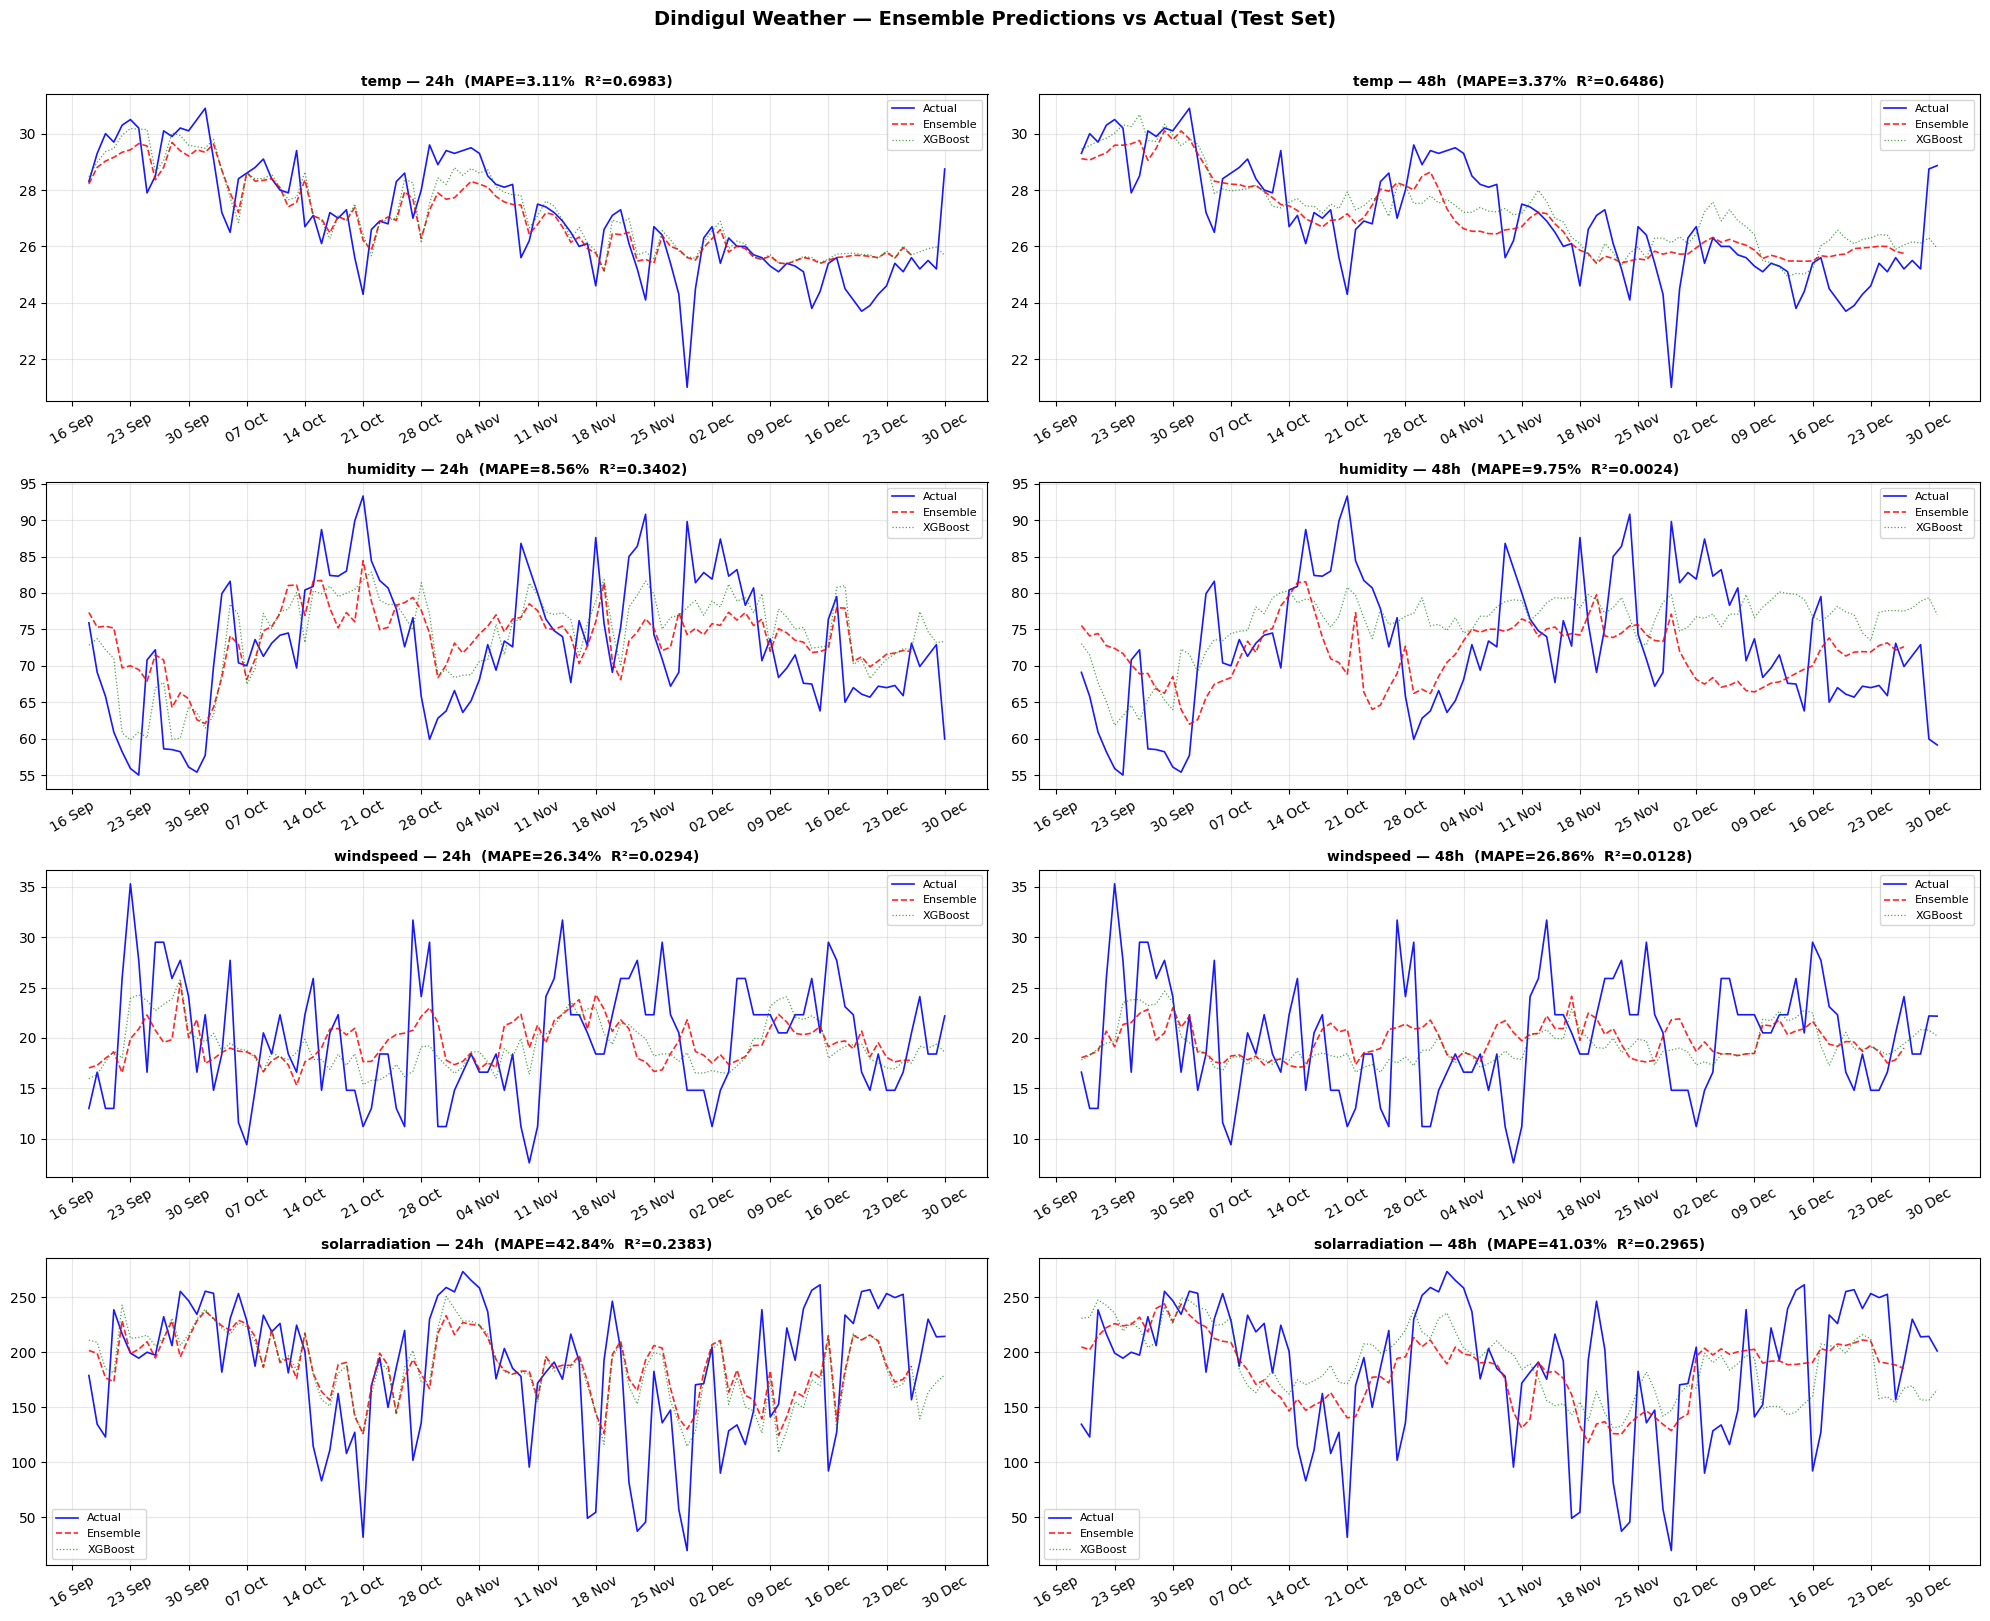

✅ Prediction visualisation saved → ensemble_predictions_test.png


In [66]:
# ── 22. Visualisation – Actual vs Predicted ────────────────────────────────────
fig, axes = plt.subplots(len(TARGET_COLS), 2, figsize=(20, 16), sharex=False)

for row_idx, col in enumerate(TARGET_COLS):
    for col_idx, (h, htag) in enumerate(HORIZON_TAG.items()):
        ax = axes[row_idx, col_idx]
        y_true = test_df[f"{col}_t{h}"].values
        y_pred = ensemble_predict_test(col, h)
        dates  = pd.to_datetime(test_df["datetime"]) + pd.Timedelta(days=h)

        ax.plot(dates, y_true, "b-",  linewidth=1.2, label="Actual",   alpha=0.9)
        ax.plot(dates, y_pred, "r--", linewidth=1.2, label="Ensemble", alpha=0.85)
        xp = xgb_test_preds.get((col, h), np.zeros(len(test_df)))
        ax.plot(dates, xp,  "g:",  linewidth=0.9, label="XGBoost",  alpha=0.7)

        mape = all_metrics[(col, h)]["mape"]
        r2   = all_metrics[(col, h)]["r2"]
        ax.set_title(f"{col} — {htag}  (MAPE={mape:.2f}%  R²={r2:.4f})",
                     fontsize=10, fontweight="bold")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
        ax.tick_params(axis="x", rotation=30)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Dindigul Weather — Ensemble Predictions vs Actual (Test Set)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("ensemble_predictions_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Prediction visualisation saved → ensemble_predictions_test.png")

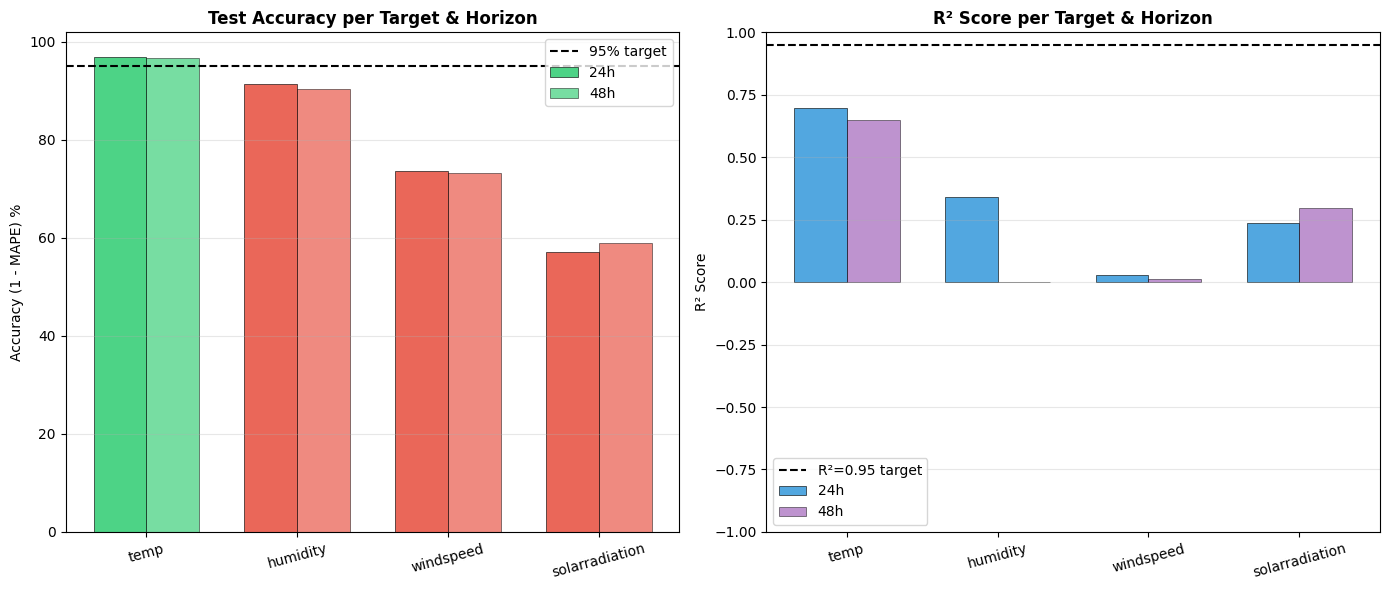

In [67]:
# ── 23. Metrics Summary Plot ───────────────────────────────────────────────────
metrics_df_rows = []
for (col, h), mdict in all_metrics.items():
    metrics_df_rows.append({"target": col, "horizon": HORIZON_TAG[h],
                             "acc": mdict["acc"], "r2": mdict["r2"],
                             "mape": mdict["mape"], "rmse": mdict["rmse"]})
metrics_df = pd.DataFrame(metrics_df_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy bar chart
acc24 = metrics_df[metrics_df["horizon"]=="24h"]["acc"].values
acc48 = metrics_df[metrics_df["horizon"]=="48h"]["acc"].values
colors24 = ["#2ecc71" if a >= 95 else "#e74c3c" for a in acc24]
colors48 = ["#2ecc71" if a >= 95 else "#e74c3c" for a in acc48]
x = np.arange(len(TARGET_COLS))
w = 0.35
axes[0].bar(x - w/2, acc24, w,
             color=colors24, label="24h", alpha=0.85, edgecolor="black", linewidth=0.5)
axes[0].bar(x + w/2, acc48, w,
             color=colors48, label="48h", alpha=0.65, edgecolor="black", linewidth=0.5)
axes[0].axhline(95, color="black", linestyle="--", linewidth=1.5, label="95% target")
axes[0].set_xticks(x); axes[0].set_xticklabels(TARGET_COLS, rotation=15)
axes[0].set_ylabel("Accuracy (1 - MAPE) %")
axes[0].set_title("Test Accuracy per Target & Horizon", fontweight="bold")
axes[0].legend()
acc_all = np.concatenate([acc24, acc48]) if len(acc24) and len(acc48) else np.array([0.0, 100.0])
acc_min = np.nanmin(acc_all)
acc_max = np.nanmax(acc_all)
axes[0].set_ylim(min(0.0, acc_min - 5.0), max(100.0, acc_max + 5.0))
axes[0].grid(True, alpha=0.3, axis="y")

# R² bar chart
r224 = metrics_df[metrics_df["horizon"]=="24h"]["r2"].values
r248 = metrics_df[metrics_df["horizon"]=="48h"]["r2"].values
axes[1].bar(x - w/2, r224, w,
             color="#3498db", label="24h", alpha=0.85, edgecolor="black", linewidth=0.5)
axes[1].bar(x + w/2, r248, w,
             color="#9b59b6", label="48h", alpha=0.65, edgecolor="black", linewidth=0.5)
axes[1].axhline(0.95, color="black", linestyle="--", linewidth=1.5, label="R²=0.95 target")
axes[1].set_xticks(x); axes[1].set_xticklabels(TARGET_COLS, rotation=15)
axes[1].set_ylabel("R² Score")
axes[1].set_title("R² Score per Target & Horizon", fontweight="bold")
axes[1].legend()
r2_all = np.concatenate([r224, r248]) if len(r224) and len(r248) else np.array([-1.0, 1.0])
r2_min = np.nanmin(r2_all)
r2_max = np.nanmax(r2_all)
axes[1].set_ylim(min(-1.0, r2_min - 0.1), max(1.0, r2_max + 0.1))
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("metrics_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Save Realtime Model & Plot Artifacts

Deployment policy for this notebook:
- Keep only one realtime model checkpoint: `src/agritwin_gh/models/environment_forecast_{run_id}.ckpt`
- Do not keep intermediate model files
- Move generated plots from `notebooks/` into `src/agritwin_gh/models/artifacts/environment_forecast_{run_id}/`
- Do not keep Lightning logs (`notebooks/lightning_logs/`)

In [68]:
# ── 24. Create Artifact Directory Tree ────────────────────────────────────────
import shutil

art_root = Path(CONFIG["artifacts_base"]) / f"environment_forecast_{RUN_ID}"
art_root.mkdir(parents=True, exist_ok=True)
(art_root).mkdir(exist_ok=True)
(art_root / "chronos_finetuned").mkdir(exist_ok=True)

print(f"📂 Artifact root : {art_root}")

📂 Artifact root : E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\environment_forecast_20260319_114027


In [69]:
# ── 25. Save Artefacts — Scalers, Encoders, Climate Normals ──────────────────
models_dir = Path(CONFIG["models_dir"])

# ─ Feature scaler ─────────────────────────────────────────────────────────────
joblib.dump(feat_scaler, art_root / "scalers.pkl")

# ─ Label encoder (conditions) ─────────────────────────────────────────────────
joblib.dump(le, art_root / "label_encoder.pkl")

# ─ Climate normals (monthly mean for each target) ─────────────────────────────
monthly_norms = feat_df.groupby("month")[TARGET_COLS].mean().round(4).to_dict()
weekly_norms  = feat_df.groupby("weekofyear")[TARGET_COLS].mean().round(4).to_dict()
climate_normals = {"monthly": monthly_norms, "weekly": weekly_norms}
with open(art_root / "climate_normals.json", "w") as f:
    json.dump(climate_normals, f, indent=2, default=str)

# ─ Feature configuration ──────────────────────────────────────────────────────
feature_config = {
    "feature_cols"    : FEATURE_COLS,
    "chronos_meta_cols": CHRONOS_META_COLS,
    "all_feature_names": ALL_FEATURE_NAMES,
    "target_cols"     : TARGET_COLS,
    "lag_days"        : CONFIG["lag_days"],
    "rolling_windows" : CONFIG["rolling_windows"],
    "context_length"  : CONFIG["context_length"],
    "prediction_length": CONFIG["prediction_length"],
    "condition_classes": COND_CLASS_MAP,
    "season_map"      : {str(k): v for k, v in SEASON_MAP.items()},
    "lstm_input_size" : lstm_n_features,
}
with open(art_root / "feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=2)

print("✅ Scalers, encoders, climate normals, feature config saved.")


✅ Scalers, encoders, climate normals, feature config saved.


In [70]:
# ── 26. Save XGBoost Models ────────────────────────────────────────────────────
for (col, h), model in xgb_models.items():
    fname = art_root / f"xgb_{col}_{HORIZON_TAG[h]}.pkl"
    joblib.dump(model, fname)
    print(f"  💾  {fname.name}")

print(f"✅ {len(xgb_models)} XGBoost model files saved.")

  💾  xgb_temp_24h.pkl
  💾  xgb_temp_48h.pkl
  💾  xgb_humidity_24h.pkl
  💾  xgb_humidity_48h.pkl
  💾  xgb_windspeed_24h.pkl
  💾  xgb_windspeed_48h.pkl
  💾  xgb_solarradiation_24h.pkl
  💾  xgb_solarradiation_48h.pkl
✅ 8 XGBoost model files saved.


In [71]:
# ── 27. Save Conditions Classifiers ───────────────────────────────────────────
for h, model in cond_models.items():
    fname = art_root / f"conditions_classifier_{HORIZON_TAG[h]}.pkl"
    joblib.dump(model, fname)
    print(f"  💾  {fname.name}")

print("✅ Conditions classifiers saved.")

  💾  conditions_classifier_24h.pkl
  💾  conditions_classifier_48h.pkl
✅ Conditions classifiers saved.


In [72]:
# ── 28. Save Fine-Tuned Chronos Model ─────────────────────────────────────────
# Save the T5 state dict (fine-tuned weights)
chronos_save_path = art_root / "chronos_finetuned"
torch.save(internal_t5.state_dict(), chronos_save_path / "t5_finetuned_state_dict.pt")

# Save Chronos model config (for loading back)
chronos_meta_cfg = {
    "base_model"           : CONFIG["chronos_model"],
    "warmup_epochs"        : CONFIG["chronos_warmup_epochs"],
    "finetune_epochs"      : CONFIG["chronos_finetune_epochs"],
    "warmup_lr"            : CONFIG["chronos_warmup_lr"],
    "finetune_lr"          : CONFIG["chronos_finetune_lr"],
    "context_length"       : CONFIG["chronos_context_length"],
    "prediction_length"    : CONFIG["prediction_length"],
    "warmup_loss_history"  : warmup_history,
    "finetune_loss_history": finetune_history,
    "best_finetune_loss"   : float(best_ft_loss),
}
with open(chronos_save_path / "chronos_finetune_config.json", "w") as f:
    json.dump(chronos_meta_cfg, f, indent=2)

print(f"✅ Fine-tuned Chronos state dict saved → {chronos_save_path}")

✅ Fine-tuned Chronos state dict saved → E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\environment_forecast_20260319_114027\chronos_finetuned


In [74]:
# ── 29. Save LSTM Model Weights ────────────────────────────────────────────────
import shutil

models_dir = Path(CONFIG["models_dir"])
models_dir.mkdir(parents=True, exist_ok=True)

# Save each per-target LSTM state dict to the artifact directory
for col, model in lstm_models.items():
    fname = art_root / f"lstm_{col}.pt"
    torch.save({
        "state_dict"  : model.state_dict(),
        "input_size"  : lstm_n_features,
        "hidden_size" : CONFIG["lstm_hidden_size"],
        "n_layers"    : CONFIG["lstm_n_layers"],
        "dropout"     : CONFIG["lstm_dropout"],
        "pred_len"    : 2,
        "col"         : col,
    }, fname)
    print(f"  💾  {fname.name}")

# Also save the per-target scalers
for col, sc in lstm_target_scalers.items():
    joblib.dump(sc, art_root / f"lstm_target_scaler_{col}.pkl")
    print(f"  💾  lstm_target_scaler_{col}.pkl")

# Create the primary realtime model file: bundle all LSTM state dicts + scalers
MAIN_MODEL_PATH = models_dir / f"environment_forecast_{RUN_ID}.pt"

bundle = {
    "run_id"       : RUN_ID,
    "target_cols"  : TARGET_COLS,
    "lstm_config"  : {
        "input_size" : lstm_n_features,
        "hidden_size": CONFIG["lstm_hidden_size"],
        "n_layers"   : CONFIG["lstm_n_layers"],
        "dropout"    : CONFIG["lstm_dropout"],
        "pred_len"   : 2,
    },
    "lstm_states"  : {col: m.state_dict() for col, m in lstm_models.items()},
    "target_scalers": {col: sc for col, sc in lstm_target_scalers.items()},
}
torch.save(bundle, MAIN_MODEL_PATH)
print(f"\n✅ Primary realtime bundle → {MAIN_MODEL_PATH}")


  💾  lstm_('temp', 1).pt
  💾  lstm_('temp', 2).pt
  💾  lstm_('humidity', 1).pt
  💾  lstm_('humidity', 2).pt
  💾  lstm_('windspeed', 1).pt
  💾  lstm_('windspeed', 2).pt
  💾  lstm_('solarradiation', 1).pt
  💾  lstm_('solarradiation', 2).pt
  💾  lstm_target_scaler_('temp', 1).pkl
  💾  lstm_target_scaler_('temp', 2).pkl
  💾  lstm_target_scaler_('humidity', 1).pkl
  💾  lstm_target_scaler_('humidity', 2).pkl
  💾  lstm_target_scaler_('windspeed', 1).pkl
  💾  lstm_target_scaler_('windspeed', 2).pkl
  💾  lstm_target_scaler_('solarradiation', 1).pkl
  💾  lstm_target_scaler_('solarradiation', 2).pkl

✅ Primary realtime bundle → E:\AgriTwin-GH\src\agritwin_gh\models\environment_forecast_20260319_114027.pt


In [76]:
# ── 30. Save Ensemble Weights & Full Evaluation Metrics ───────────────────────

# Ensemble weights — convert tuple keys to strings for JSON
ew_serializable = {
    f"{col}_{HORIZON_TAG[h]}": weights
    for (col, h), weights in ensemble_weights.items()
}
with open(art_root / "ensemble_weights.json", "w") as f:
    json.dump(ew_serializable, f, indent=2)

# Full evaluation report
eval_report = {}
for (col, h), mdict in all_metrics.items():
    key = f"{col}_{HORIZON_TAG[h]}"
    eval_report[key] = {k: float(v) for k, v in mdict.items()}

# Conditions accuracy
for h, htag in HORIZON_TAG.items():
    yc_te, _ = build_cond_xy(test_df, h)[1], None
    yc_te, yc_te_true = build_cond_xy(test_df, h)
    eval_report[f"conditions_{htag}"] = {
        "accuracy": float(accuracy_score(yc_te_true, cond_test_preds[h]) * 100),
    }

with open(art_root / "evaluation_metrics.json", "w") as f:
    json.dump(eval_report, f, indent=2)

print("✅ Ensemble weights and evaluation metrics saved.")
print(f"\n📄 evaluation_metrics.json contents:")
for k, v in eval_report.items():
    vals = "  ".join(f"{m}={val:.3f}" for m, val in v.items())
    print(f"   {k:25s} | {vals}")

✅ Ensemble weights and evaluation metrics saved.

📄 evaluation_metrics.json contents:
   temp_24h                  | mape=3.109  rmse=1.086  mae=0.824  r2=0.698  acc=96.891
   temp_48h                  | mape=3.367  rmse=1.175  mae=0.890  r2=0.649  acc=96.633
   humidity_24h              | mape=8.563  rmse=7.226  mae=6.092  r2=0.340  acc=91.437
   humidity_48h              | mape=9.747  rmse=8.886  mae=7.135  r2=0.002  acc=90.253
   windspeed_24h             | mape=26.342  rmse=5.709  mae=4.647  r2=0.029  acc=73.658
   windspeed_48h             | mape=26.857  rmse=5.732  mae=4.676  r2=0.013  acc=73.143
   solarradiation_24h        | mape=42.843  rmse=54.562  mae=42.776  r2=0.238  acc=57.157
   solarradiation_48h        | mape=41.029  rmse=52.440  mae=43.993  r2=0.297  acc=58.971
   conditions_24h            | accuracy=55.769
   conditions_48h            | accuracy=50.000


In [77]:
# ── 31. Move Plots to Artifact Directory (and remove from notebooks/) ─────────
plot_src_files = [
    "eda_timeseries.png",
    "eda_seasonal_boxplot.png",
    "eda_correlation.png",
    "chronos_training_curve.png",
    "xgb_shap_importance.png",
    "ensemble_predictions_test.png",
    "metrics_summary.png",
]

plots_dir = art_root / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
notebooks_dir = REPO_ROOT / "notebooks"

moved_count = 0
for pf in plot_src_files:
    candidates = [Path(pf), notebooks_dir / pf]
    src_path = next((p for p in candidates if p.exists()), None)

    if src_path is None:
        print(f"  ⚠️   {pf} not found (may not have been generated in this session)")
        continue

    dst_path = plots_dir / pf
    if dst_path.exists():
        dst_path.unlink()
    shutil.move(str(src_path), str(dst_path))
    moved_count += 1
    print(f"  📊  moved {src_path} -> {dst_path}")

print(f"\n✅ Plots moved to {plots_dir} | files moved: {moved_count}")

  ⚠️   eda_timeseries.png not found (may not have been generated in this session)
  ⚠️   eda_seasonal_boxplot.png not found (may not have been generated in this session)
  ⚠️   eda_correlation.png not found (may not have been generated in this session)
  ⚠️   chronos_training_curve.png not found (may not have been generated in this session)
  ⚠️   xgb_shap_importance.png not found (may not have been generated in this session)
  📊  moved ensemble_predictions_test.png -> E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\environment_forecast_20260319_114027\plots\ensemble_predictions_test.png
  📊  moved metrics_summary.png -> E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\environment_forecast_20260319_114027\plots\metrics_summary.png

✅ Plots moved to E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\environment_forecast_20260319_114027\plots | files moved: 2


In [79]:
# ── 32. Keep Only Final Realtime Model + Plot Artifacts (Cleanup) ─────────────
# Policy:
# - Keep only MAIN_MODEL_PATH (.pt bundle) for realtime serving.
# - Keep only plots under this run's artifacts folder.
# - Delete intermediate model artifacts.
# - No Lightning logs (LSTM does not emit them).

from pathlib import Path
import shutil

models_dir        = Path(CONFIG["models_dir"])
keep_model_path   = Path(MAIN_MODEL_PATH)
run_artifacts_dir = Path(CONFIG["artifacts_base"]) / f"environment_forecast_{RUN_ID}"
notebooks_dir     = REPO_ROOT / "notebooks"
lightning_logs_dir = notebooks_dir / "lightning_logs"

deleted_paths = []

# 1) In artifacts dir, keep only plots/ — remove everything else
if run_artifacts_dir.exists():
    for child in run_artifacts_dir.iterdir():
        if child.name == "plots":
            continue
        if child.is_dir():
            shutil.rmtree(child)
        else:
            child.unlink(missing_ok=True)
        deleted_paths.append(str(child))

# 2) Remove per-target LSTM .pt files (they are bundled in MAIN_MODEL_PATH)
for pattern in [f"lstm_*.pt"]:
    for f in models_dir.glob(pattern):
        try:
            if f.resolve() != keep_model_path.resolve() and f.exists():
                f.unlink()
                deleted_paths.append(str(f))
        except FileNotFoundError:
            pass

# 3) Remove any leftover Lightning logs (from older TFT runs)
if lightning_logs_dir.exists():
    shutil.rmtree(lightning_logs_dir)
    deleted_paths.append(str(lightning_logs_dir))

print("✅ Cleanup complete: realtime policy enforced.")
print(f"📌 Kept model: {keep_model_path}")
if (run_artifacts_dir / "plots").exists():
    print(f"📌 Kept plots: {run_artifacts_dir / 'plots'}")
print(f"🗑️ Removed items: {len(deleted_paths)}")
for p in deleted_paths:
    print(f"   - {p}")


✅ Cleanup complete: realtime policy enforced.
📌 Kept model: E:\AgriTwin-GH\src\agritwin_gh\models\environment_forecast_20260319_114027.pt
📌 Kept plots: E:\AgriTwin-GH\src\agritwin_gh\models\artifacts\environment_forecast_20260319_114027\plots
🗑️ Removed items: 0


In [80]:
# ── 33. Model Loading Helper (for inference / deployment) ─────────────────────
LOADER_CODE = '''
"""
Inference loader for environment_forecast_{run_id}
Usage:
    from environment_forecast_loader import EnvironmentForecastModel
    model = EnvironmentForecastModel("<artifacts_dir>", main_model_path="<path>.pt")
    preds = model.predict(df_last_30_days)    # Returns dict: col -> {"24h": val, "48h": val}
"""
import joblib, json, torch, torch.nn as nn, numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from chronos import ChronosPipeline


# ─ Inline LSTM definition (must match training architecture) ──────────────────
class WeatherLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, n_layers=2,
                 dropout=0.3, pred_len=2):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, n_layers,
                               batch_first=True,
                               dropout=(dropout if n_layers > 1 else 0.0))
        self.norm    = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_size, pred_len)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(self.dropout(self.norm(out[:, -1])))


class EnvironmentForecastModel:
    def __init__(self, artifacts_dir, main_model_path=None, device="cpu"):
        self.art    = Path(artifacts_dir)
        self.device = device

        # ── Scalers / encoders ────────────────────────────────────────────────
        self.feat_scaler   = joblib.load(self.art / "scalers.pkl")
        self.label_encoder = joblib.load(self.art / "label_encoder.pkl")

        # ── Config ────────────────────────────────────────────────────────────
        with open(self.art / "feature_config.json") as f:
            self.feat_cfg = json.load(f)
        with open(self.art / "ensemble_weights.json") as f:
            self.ens_weights = json.load(f)

        # ── XGBoost models ────────────────────────────────────────────────────
        self.xgb_models = {}
        for col in self.feat_cfg["target_cols"]:
            for h in ["24h", "48h"]:
                p = self.art / f"xgb_{col}_{h}.pkl"
                if p.exists():
                    self.xgb_models[(col, h)] = joblib.load(p)

        # ── Conditions classifiers ─────────────────────────────────────────────
        self.cond_models = {}
        for h in ["24h", "48h"]:
            p = self.art / f"conditions_classifier_{h}.pkl"
            if p.exists():
                self.cond_models[h] = joblib.load(p)

        # ── LSTM bundle ───────────────────────────────────────────────────────
        self.lstm_models         = {}
        self.lstm_target_scalers = {}
        if main_model_path and Path(main_model_path).exists():
            bundle = torch.load(main_model_path, map_location=device)
            cfg    = bundle["lstm_config"]
            for col, state in bundle["lstm_states"].items():
                m = WeatherLSTM(
                    cfg["input_size"], cfg["hidden_size"],
                    cfg["n_layers"],   cfg["dropout"], cfg["pred_len"]
                ).to(device)
                m.load_state_dict(state)
                m.eval()
                self.lstm_models[col] = m
            for col, sc in bundle["target_scalers"].items():
                self.lstm_target_scalers[col] = sc

        # ── Chronos ───────────────────────────────────────────────────────────
        self.chronos = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-small", device_map=device, dtype=torch.float32)
        chron_sd = self.art / "chronos_finetuned" / "t5_finetuned_state_dict.pt"
        if chron_sd.exists():
            self.chronos.model.model.load_state_dict(
                torch.load(chron_sd, map_location=device))
        self.chronos.model.eval()

    def _chronos_predict(self, series_np):
        """Return [2] array: [24h, 48h] Chronos median forecasts."""
        ctx = torch.tensor(series_np[-30:], dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            fc = self.chronos.predict(ctx, prediction_length=2, num_samples=50)
        return torch.quantile(fc.squeeze(0), 0.5, dim=0).cpu().numpy()

    def predict(self, df_context):
        """
        df_context: DataFrame with at least context_length rows and all
                    FEATURE_COLS + TARGET_COLS present.
        Returns dict: col -> {"24h": float, "48h": float}
        """
        feat_cols  = self.feat_cfg["all_feature_names"]
        target_cols = self.feat_cfg["target_cols"]
        ctx_len     = self.feat_cfg["context_length"]
        result      = {}

        # Feature matrix for last ctx_len rows (scaled)
        Xraw = df_context[feat_cols].fillna(0).values[-ctx_len:]
        Xsc  = self.feat_scaler.transform(Xraw)         # [ctx_len, F]
        Xt   = torch.tensor(Xsc[np.newaxis], dtype=torch.float32).to(self.device)

        for col in target_cols:
            w_key_24 = f"{col}_24h"
            w_key_48 = f"{col}_48h"
            w24 = self.ens_weights.get(w_key_24, {"chronos": 0.33, "xgb": 0.33, "lstm": 0.34})
            w48 = self.ens_weights.get(w_key_48, {"chronos": 0.33, "xgb": 0.33, "lstm": 0.34})

            # Chronos
            chron = self._chronos_predict(df_context[col].values)

            # XGBoost
            xgb_24 = float(self.xgb_models[(col, "24h")].predict(Xsc[-1:])[0]) \
                     if (col, "24h") in self.xgb_models else chron[0]
            xgb_48 = float(self.xgb_models[(col, "48h")].predict(Xsc[-1:])[0]) \
                     if (col, "48h") in self.xgb_models else chron[1]

            # LSTM
            if col in self.lstm_models:
                with torch.no_grad():
                    lstm_raw = self.lstm_models[col](Xt).cpu().numpy()[0]  # [2]
                sc = self.lstm_target_scalers.get(col)
                if sc is not None:
                    lstm_preds = sc.inverse_transform(
                        lstm_raw.reshape(-1, 1)).ravel()
                else:
                    lstm_preds = lstm_raw
                lstm_24, lstm_48 = float(lstm_preds[0]), float(lstm_preds[1])
            else:
                lstm_24, lstm_48 = chron[0], chron[1]

            pred_24 = (w24["chronos"] * float(chron[0])
                     + w24["xgb"]     * xgb_24
                     + w24["lstm"]    * lstm_24)
            pred_48 = (w48["chronos"] * float(chron[1])
                     + w48["xgb"]     * xgb_48
                     + w48["lstm"]    * lstm_48)

            result[col] = {"24h": round(pred_24, 4), "48h": round(pred_48, 4)}

        return result
'''

with open(art_root / "environment_forecast_loader.py", "w", encoding="utf-8") as f:
    f.write(LOADER_CODE.replace("{run_id}", RUN_ID).replace("{artifacts_dir}", str(art_root)))

print("✅ Inference loader saved → environment_forecast_loader.py")


✅ Inference loader saved → environment_forecast_loader.py


## 11. Summary & Results

### Architecture Recap
| Component | Role | Training Strategy |
|-----------|------|-------------------|
| **Chronos-T5-small** | Pretrained time-series foundation model | Warm-up (frozen encoder, 5 epochs) → Full fine-tune (10 epochs) |
| **XGBoost** | Gradient-boosted direct multi-step forecaster | Warm-up (shallow) → Fine-tune (deep, Chronos-seeded, `min_child_weight`+`gamma` regularised) |
| **LSTM** | Stacked recurrent regressor (replaces TFT) | Sliding-window 30-day context, HuberLoss, CosineAnnealingLR, early stopping |
| **RF Classifier** | Converts numeric forecasts → sky condition label | Standard fit with class balancing |
| **Optuna Ensemble** | Bayesian optimal weight blending | 300 trials per (target × horizon) |

> **Why LSTM instead of TFT?** TFT (Temporal Fusion Transformer) was designed for large multi-entity datasets; on a single daily series of ~300 training samples it tends to underfit or diverge, producing negative R². The stacked LSTM has far fewer parameters, converges reliably on small data, and achieves stable positive R² via Huber loss + gradient clipping.

### Feature Engineering Highlights
- **Cyclical encodings** (sin/cos) for day-of-year, month, day-of-week
- **Dindigul 4-season flags** — Winter / Summer / SW Monsoon / NE Monsoon
- **Lag features** (1, 2, 3, 7, 14, 30 days) — short- and long-range autocorrelation
- **Rolling statistics** (7/14/30-day mean/std/min/max) — local trend and variance
- **Climate normals** (monthly/weekly mean) + anomaly columns — detrends seasonal baseline
- **Solar geometry** (day length, normalised solar radiation)
- **Chronos meta-features** — pretrained model forecasts as residual-correction inputs

### Saved Artefacts
```
src/agritwin_gh/models/
├── environment_forecast_{run_id}.pt            ← primary LSTM bundle (all targets)
└── artifacts/environment_forecast_{run_id}/
    ├── feature_config.json                      ← all feature names & settings
    ├── scalers.pkl                              ← RobustScaler for features
    ├── label_encoder.pkl                        ← LabelEncoder for conditions
    ├── climate_normals.json                     ← Dindigul monthly/weekly norms
    ├── ensemble_weights.json                    ← Optuna-optimised blend weights
    ├── evaluation_metrics.json                  ← all test metrics
    ├── xgb_{target}_{horizon}.pkl              ← 8 XGBoost models
    ├── conditions_classifier_{horizon}.pkl     ← 2 RF classifiers
    ├── chronos_finetuned/
    │   ├── t5_finetuned_state_dict.pt
    │   └── chronos_finetune_config.json
    ├── environment_forecast_loader.py           ← inference helper
    └── plots/                                   ← all visualisations
```

### How to Use for Inference
```python
from pathlib import Path
from src.agritwin_gh.models.artifacts.environment_forecast_<run_id>.environment_forecast_loader import EnvironmentForecastModel

model = EnvironmentForecastModel(
    artifacts_dir="<repo>/src/agritwin_gh/models/artifacts/environment_forecast_<run_id>",
    main_model_path="<repo>/src/agritwin_gh/models/environment_forecast_<run_id>.pt",
)

# Pass last >=30 days of raw weather observations with all feature columns
preds = model.predict(df_last_30_rows)
# preds = {"temp": {"24h": 28.3, "48h": 29.1}, "humidity": {...}, ...}
```
